<a href="https://colab.research.google.com/github/chebyshevtech/proteinthoughts/blob/main/protein_thoughts_PPIProjectedNet_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Run once, then restart runtime if needed
!pip install torch torchvision torchaudio --quiet
!pip install numpy pandas scikit-learn matplotlib seaborn tqdm --quiet

# For ESM-2 embeddings (optional but recommended — skip if GPU is small)
!pip install fair-esm --quiet

# For downloading the STRING/SHS datasets
!pip install gdown --quiet

print('✓ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 9.0 MB/s eta 0:00:00
✓ Dependencies installed


In [2]:
import os
import json
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, f1_score,
    confusion_matrix
)

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Imports ready  |  device = {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

✓ Imports ready  |  device = cuda
  GPU: NVIDIA A100-SXM4-40GB


In [3]:
# Cell 3 — Download SHS27k, SHS148k from Zenodo + STRING from Google Drive

import os
import subprocess

DATA_ROOT = './data'
os.makedirs(DATA_ROOT, exist_ok=True)

# SHS27k and SHS148k — direct from Zenodo (no auth needed)
ZENODO_FILES = {
    'SHS27k.actions.txt':  'https://zenodo.org/records/15694560/files/SHS27k.actions.txt?download=1',
    'SHS27k.seqs.tsv':     'https://zenodo.org/records/15694560/files/SHS27k.seqs.tsv?download=1',
    'SHS148k.actions.txt': 'https://zenodo.org/records/15694560/files/SHS148k.actions.txt?download=1',
    'SHS148k.seqs.tsv':    'https://zenodo.org/records/15694560/files/SHS148k.seqs.tsv?download=1',
}

for fname, url in ZENODO_FILES.items():
    dest = os.path.join(DATA_ROOT, fname)
    if os.path.exists(dest) and os.path.getsize(dest) > 1000:
        print(f'✓ {fname} already present ({os.path.getsize(dest)//1024} KB)')
    else:
        print(f'Downloading {fname} ...')
        subprocess.run(['wget', '-q', '--show-progress', '-O', dest, url], check=True)
        print(f'  ✓ saved ({os.path.getsize(dest)//1024} KB)')


  ✓ saved (3865 KB)
  ✓ saved (978 KB)
  ✓ saved (22496 KB)
  ✓ saved (3134 KB)


In [4]:
# Cell 3b — Download STRING files from official STRING DB
# (replaces the failed Google Drive links)

import os, subprocess, gzip, shutil

DATA_ROOT = './data'

# STRING v11 protein actions (human, 9606)
# This is the same file used by PIPR/HIGH-PPI, just fetched from the real source
STRING_LINKS_URL = 'https://stringdb-downloads.org/download/protein.actions.v11.0/9606.protein.actions.v11.0.txt.gz'
STRING_SEQS_URL  = 'https://stringdb-downloads.org/download/protein.sequences.v11.0/9606.protein.sequences.v11.0.fa.gz'

def download_and_gunzip(url, dest_gz, dest_out):
    if os.path.exists(dest_out) and os.path.getsize(dest_out) > 10000:
        print(f'✓ {os.path.basename(dest_out)} already present ({os.path.getsize(dest_out)//1024} KB)')
        return
    print(f'Downloading {os.path.basename(dest_gz)} ...')
    subprocess.run(['wget', '-q', '--show-progress', '-O', dest_gz, url], check=True)
    print(f'  Decompressing ...')
    with gzip.open(dest_gz, 'rb') as f_in, open(dest_out, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(dest_gz)
    print(f'  ✓ saved ({os.path.getsize(dest_out)//1024} KB)')

download_and_gunzip(
    STRING_LINKS_URL,
    os.path.join(DATA_ROOT, '9606.protein.actions.v11.0.txt.gz'),
    os.path.join(DATA_ROOT, '9606.protein.action.v11.0.txt'),
)

download_and_gunzip(
    STRING_SEQS_URL,
    os.path.join(DATA_ROOT, '9606.protein.sequences.v11.0.fa.gz'),
    os.path.join(DATA_ROOT, '9606.protein.sequences.v11.0.fa'),
)

print('\nFiles in ./data/:')
for f in sorted(os.listdir(DATA_ROOT)):
    path = os.path.join(DATA_ROOT, f)
    if os.path.isfile(path):
        print(f'  {f}  ({os.path.getsize(path)//1024} KB)')

  Decompressing ...
  ✓ saved (206300 KB)
  Decompressing ...
  ✓ saved (11489 KB)

Files in ./data/:
  9606.protein.action.v11.0.txt  (206300 KB)
  9606.protein.sequences.v11.0.fa  (11489 KB)
  SHS148k.actions.txt  (22496 KB)
  SHS148k.seqs.tsv  (3134 KB)
  SHS27k.actions.txt  (3865 KB)
  SHS27k.seqs.tsv  (978 KB)


## Takes 7 mins for cell below

In [5]:
# Parse all three datasets into (seq_a, seq_b, label, split) DataFrames

import os
import numpy as np
import pandas as pd
from collections import defaultdict

SEED = 42
DATA_ROOT = './data'

# ── 1. Sequence loaders ───────────────────────────────────────────────────────

def load_tsv_seqs(path):
    """Parse SHS27k/SHS148k .seqs.tsv  →  {protein_id: sequence}"""
    seq_map = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split('\t')
            if len(parts) >= 2:
                seq_map[parts[0].strip()] = parts[1].strip()
    print(f'  Loaded {len(seq_map)} sequences from {os.path.basename(path)}')
    return seq_map


def load_fasta_seqs(path):
    """Parse STRING FASTA  →  {protein_id: sequence}"""
    seq_map = {}
    current_id, current_seq = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_id:
                    seq_map[current_id] = ''.join(current_seq)
                current_id = line[1:].split()[0]   # first token after '>'
                current_seq = []
            else:
                current_seq.append(line)
    if current_id:
        seq_map[current_id] = ''.join(current_seq)
    print(f'  Loaded {len(seq_map)} sequences from {os.path.basename(path)}')
    return seq_map


# ── 2. Actions loader ─────────────────────────────────────────────────────────

def load_actions(path, score_col='score', score_threshold=0, max_rows=None):
    """
    Parse *.actions.txt  (tab-separated, first row = header).
    Returns DataFrame with at minimum columns [id_a, id_b].
    """
    df = pd.read_csv(path, sep='\t', nrows=max_rows)
    df.columns = [c.strip() for c in df.columns]

    # normalise column names across STRING vs SHS files
    rename = {}
    for c in df.columns:
        cl = c.lower()
        if cl in ('item_id_a', 'protein1', 'id_a'):
            rename[c] = 'id_a'
        elif cl in ('item_id_b', 'protein2', 'id_b'):
            rename[c] = 'id_b'
        elif cl == 'score':
            rename[c] = 'score'
    df = df.rename(columns=rename)

    if 'score' in df.columns and score_threshold > 0:
        df = df[df['score'] >= score_threshold]

    # deduplicate: keep one direction
    df = df[['id_a', 'id_b']].drop_duplicates()
    print(f'  Loaded {len(df)} action pairs from {os.path.basename(path)}')
    return df


# ── 3. Build balanced pos/neg dataset ────────────────────────────────────────

def build_dataset(actions_df, seq_map, neg_ratio=1.0, max_pos=None, seed=42):
    rng = np.random.default_rng(seed)

    # positive pairs
    pos = []
    for _, row in actions_df.iterrows():
        a, b = row['id_a'], row['id_b']
        if a in seq_map and b in seq_map:
            pos.append((a, b, seq_map[a], seq_map[b], 1))

    if max_pos and len(pos) > max_pos:
        idx = rng.choice(len(pos), max_pos, replace=False)
        pos = [pos[i] for i in idx]

    print(f'  Positive pairs with sequences: {len(pos)}')

    # negative pairs — random sampling of non-interacting pairs
    pos_set = set((a, b) for a, b, *_ in pos)
    pos_set |= set((b, a) for a, b, *_ in pos)
    all_prots = list(seq_map.keys())
    n_neg = int(len(pos) * neg_ratio)
    neg = []
    attempts = 0
    while len(neg) < n_neg and attempts < n_neg * 30:
        a, b = rng.choice(all_prots, 2, replace=False)
        if (a, b) not in pos_set:
            neg.append((a, b, seq_map[a], seq_map[b], 0))
            pos_set.add((a, b))
        attempts += 1

    print(f'  Negative pairs sampled:        {len(neg)}')

    rows = pos + neg
    rng.shuffle(rows)
    df = pd.DataFrame(rows, columns=['id_a', 'id_b', 'seq_a', 'seq_b', 'label'])
    return df


# ── 4. DFS split (70 / 10 / 20) ─────────────────────────────────

def dfs_split(df, train_frac=0.70, val_frac=0.10, seed=42):
    rng = np.random.default_rng(seed)
    adj = defaultdict(set)
    for _, row in df[df['label'] == 1].iterrows():
        adj[row['id_a']].add(row['id_b'])
        adj[row['id_b']].add(row['id_a'])

    proteins = list(set(df['id_a'].tolist() + df['id_b'].tolist()))
    rng.shuffle(proteins)

    visited, order = {}, []
    for start in proteins:
        if start not in visited:
            stack = [start]
            while stack:
                node = stack.pop()
                if node not in visited:
                    visited[node] = True
                    order.append(node)
                    nbrs = list(adj[node])
                    rng.shuffle(nbrs)
                    stack.extend(nbrs)

    n = len(order)
    tr_cut = int(n * train_frac)
    va_cut  = int(n * (train_frac + val_frac))
    split_map = {}
    for i, node in enumerate(order):
        split_map[node] = 'train' if i < tr_cut else ('val' if i < va_cut else 'test')

    rank = {'train': 0, 'val': 1, 'test': 2}
    df = df.copy()
    df['split'] = df.apply(
        lambda r: max(split_map.get(r['id_a'], 'train'),
                      split_map.get(r['id_b'], 'train'),
                      key=lambda s: rank[s]),
        axis=1
    )
    return df


# ─────────────────────────────────────────────────────────────────────────────
# Build each dataset
# ─────────────────────────────────────────────────────────────────────────────

print('── SHS27k ──')
shs27_seqs    = load_tsv_seqs(os.path.join(DATA_ROOT, 'SHS27k.seqs.tsv'))
shs27_actions = load_actions(os.path.join(DATA_ROOT, 'SHS27k.actions.txt'))
df_shs27 = build_dataset(shs27_actions, shs27_seqs, seed=SEED)
df_shs27 = dfs_split(df_shs27, seed=SEED)
df_shs27['dataset'] = 'SHS27k'
print(f'  Total: {len(df_shs27)}  pos={df_shs27["label"].mean():.3f}  splits={df_shs27["split"].value_counts().to_dict()}')

print('\n── SHS148k ──')
shs148_seqs    = load_tsv_seqs(os.path.join(DATA_ROOT, 'SHS148k.seqs.tsv'))
shs148_actions = load_actions(os.path.join(DATA_ROOT, 'SHS148k.actions.txt'))
df_shs148 = build_dataset(shs148_actions, shs148_seqs, seed=SEED)
df_shs148 = dfs_split(df_shs148, seed=SEED)
df_shs148['dataset'] = 'SHS148k'
print(f'  Total: {len(df_shs148)}  pos={df_shs148["label"].mean():.3f}  splits={df_shs148["split"].value_counts().to_dict()}')

print('\n── STRING ──')
string_seqs    = load_fasta_seqs(os.path.join(DATA_ROOT, '9606.protein.sequences.v11.0.fa'))
string_actions = load_actions(
    os.path.join(DATA_ROOT, '9606.protein.action.v11.0.txt'),
    score_threshold=700   # high-confidence only, same as benchmark papers
)
df_string = build_dataset(string_actions, string_seqs, max_pos=100_000, seed=SEED)
df_string = dfs_split(df_string, seed=SEED)
df_string['dataset'] = 'STRING'
print(f'  Total: {len(df_string)}  pos={df_string["label"].mean():.3f}  splits={df_string["split"].value_counts().to_dict()}')

# ── Final summary ─────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('SUMMARY')
print('='*55)
datasets = {'SHS27k': df_shs27, 'SHS148k': df_shs148, 'STRING': df_string}
for name, df in datasets.items():
    print(f'{name:10s}  {len(df):>8,} pairs  pos={df["label"].mean():.3f}  '
          f'train={sum(df["split"]=="train"):,}  '
          f'val={sum(df["split"]=="val"):,}  '
          f'test={sum(df["split"]=="test"):,}')

── SHS27k ──
  Loaded 1690 sequences from SHS27k.seqs.tsv
  Loaded 15248 action pairs from SHS27k.actions.txt
  Positive pairs with sequences: 15248
  Negative pairs sampled:        15248
  Total: 30496  pos=0.500  splits={'train': 20618, 'test': 6741, 'val': 3137}

── SHS148k ──
  Loaded 5189 sequences from SHS148k.seqs.tsv
  Loaded 88976 action pairs from SHS148k.actions.txt
  Positive pairs with sequences: 88976
  Negative pairs sampled:        88976
  Total: 177952  pos=0.500  splits={'train': 122245, 'test': 37242, 'val': 18465}

── STRING ──
  Loaded 19566 sequences from 9606.protein.sequences.v11.0.fa
  Loaded 581246 action pairs from 9606.protein.action.v11.0.txt
  Positive pairs with sequences: 100000
  Negative pairs sampled:        100000
  Total: 200000  pos=0.500  splits={'train': 148967, 'test': 36038, 'val': 14995}

SUMMARY
SHS27k        30,496 pairs  pos=0.500  train=20,618  val=3,137  test=6,741
SHS148k      177,952 pairs  pos=0.500  train=122,245  val=18,465  test=37,

In [6]:
# Cell 13 — ESM-2 35M + stronger regularisation + label smoothing

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import defaultdict

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Upgrade to ESM-2 35M (12 layers, 480-dim) for richer embeddings
# ─────────────────────────────────────────────────────────────────────────────
EMBED_CACHE_35M = './data/shs27k_esm2_35M_embeddings.npz'

if os.path.exists(EMBED_CACHE_35M):
    print(f'Loading cached 35M embeddings ...')
    cache = np.load(EMBED_CACHE_35M, allow_pickle=True)
    emb_map_35m = {k: v for k, v in zip(cache['ids'], cache['embs'])}
    print(f'✓ Loaded {len(emb_map_35m)} embeddings  dim={next(iter(emb_map_35m.values())).shape}')
else:
    print('Loading ESM-2 35M ...')
    esm_model_35m, alphabet_35m = esm.pretrained.esm2_t12_35M_UR50D()
    esm_model_35m = esm_model_35m.eval().to(DEVICE)
    batch_converter_35m = alphabet_35m.get_batch_converter()
    print('✓ ESM-2 35M loaded  (dim=480, 12 layers)')

    @torch.no_grad()
    def get_esm35m_embedding(sequences, batch_size=32):
        all_embs = []
        for i in tqdm(range(0, len(sequences), batch_size), desc='ESM-2 35M'):
            batch = sequences[i:i+batch_size]
            data  = [(f'p{j}', s[:1022]) for j, s in enumerate(batch)]
            _, _, tokens = batch_converter_35m(data)
            tokens = tokens.to(DEVICE)
            out  = esm_model_35m(tokens, repr_layers=[12], return_contacts=False)
            reps = out['representations'][12]
            for j, (_, seq) in enumerate(data):
                emb = reps[j, 1:len(seq)+1].mean(0).cpu().numpy()
                all_embs.append(emb)
        return np.stack(all_embs).astype(np.float32)

    # collect unique sequences
    all_seqs_35m = {}
    for _, row in df_shs27.iterrows():
        a, b = clean_seq(row['seq_a']), clean_seq(row['seq_b'])
        all_seqs_35m[row['id_a']] = a
        all_seqs_35m[row['id_b']] = b

    ids_35m  = list(all_seqs_35m.keys())
    seqs_35m = [all_seqs_35m[i] for i in ids_35m]
    print(f'Unique proteins: {len(seqs_35m)}')

    embs_35m    = get_esm35m_embedding(seqs_35m, batch_size=32)
    emb_map_35m = {pid: emb for pid, emb in zip(ids_35m, embs_35m)}
    np.savez_compressed(EMBED_CACHE_35M,
                        ids=np.array(ids_35m),
                        embs=embs_35m)
    print(f'✓ Saved to {EMBED_CACHE_35M}')
    del esm_model_35m  # free GPU memory


Loading ESM-2 35M ...


NameError: name 'esm' is not defined

## projected 4 scores net

In [26]:
# Cell 14 - PPIProjectedNet (self-contained)

# ── Imports ───────────────────────────────────────────────────────────────────
import os, math, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from tqdm.auto import tqdm

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(SEED)
print(f'device: {DEVICE}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Load cached ESM-2 35M embeddings
# (computed in Cell 13 — file must exist at this path)
# ─────────────────────────────────────────────────────────────────────────────
EMBED_CACHE_35M = './data/shs27k_esm2_35M_embeddings.npz'
assert os.path.exists(EMBED_CACHE_35M), \
    f'Missing {EMBED_CACHE_35M} — run Cell 13 first to generate embeddings'

cache       = np.load(EMBED_CACHE_35M, allow_pickle=True)
emb_map_35m = {k: v for k, v in zip(cache['ids'], cache['embs'])}
EMB_DIM     = next(iter(emb_map_35m.values())).shape[0]   # 480
print(f'Loaded {len(emb_map_35m)} ESM-2 35M embeddings  dim={EMB_DIM}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — Redefine score functions (self-contained)
# ─────────────────────────────────────────────────────────────────────────────
AA20      = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX = {aa: i for i, aa in enumerate(AA20)}
AA_SET    = set(AA20)
AA_PROP   = {
    'A':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=89.1),
    'C':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=121.2),
    'D':dict(hydro=0,polar=1,charge=-1, arom=0,small=1,mw=133.1),
    'E':dict(hydro=0,polar=1,charge=-1, arom=0,small=0,mw=147.1),
    'F':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=165.2),
    'G':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=75.1),
    'H':dict(hydro=0,polar=1,charge=0.5,arom=1,small=0,mw=155.2),
    'I':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'K':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=146.2),
    'L':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'M':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=149.2),
    'N':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=132.1),
    'P':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=115.1),
    'Q':dict(hydro=0,polar=1,charge=0,  arom=0,small=0,mw=146.2),
    'R':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=174.2),
    'S':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=105.1),
    'T':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=119.1),
    'V':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=117.1),
    'W':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=204.2),
    'Y':dict(hydro=1,polar=1,charge=0,  arom=1,small=0,mw=181.2),
}

def _build_mj():
    M = np.zeros((20,20), dtype=np.float32)
    for i,a in enumerate(AA20):
        for j,b in enumerate(AA20):
            pa,pb = AA_PROP[a],AA_PROP[b]
            s = 0.0
            if pa['hydro'] and pb['hydro']:                                         s += 0.6
            if pa['arom']  and pb['arom']:                                          s += 0.4
            if pa['charge']*pb['charge'] < 0:                                       s += 0.9
            if pa['charge']*pb['charge'] > 0:                                       s -= 0.5
            if pa['polar'] and pb['polar'] and pa['charge']==0 and pb['charge']==0: s += 0.3
            s -= 0.01*abs(pa['mw']-pb['mw'])
            M[i,j] = s
    return (M+M.T)/2
MJ = _build_mj()

def clean_seq(s):
    return ''.join(c for c in str(s).upper() if c in AA_SET)

def kmer_jaccard(a, b, k=3):
    a,b = clean_seq(a), clean_seq(b)
    if len(a)<k or len(b)<k: return 0.0
    A = set(a[i:i+k] for i in range(len(a)-k+1))
    B = set(b[i:i+k] for i in range(len(b)-k+1))
    d = len(A|B); return float(len(A&B)/d) if d else 0.0

def profile_curve(seq, bins=64):
    seq = clean_seq(seq)
    if not seq: return np.zeros((bins,6), dtype=np.float32)
    arr = np.array([[AA_PROP[c]['hydro'],AA_PROP[c]['polar'],AA_PROP[c]['charge'],
                     AA_PROP[c]['arom'],AA_PROP[c]['small'],AA_PROP[c]['mw']/200.0]
                    for c in seq], dtype=np.float32)
    xo = np.linspace(0,1,len(arr)); xn = np.linspace(0,1,bins)
    return np.column_stack([np.interp(xn,xo,arr[:,j]) for j in range(6)]).astype(np.float32)

def structure_proxy_score(a, b):
    A,B = profile_curve(a).ravel(), profile_curve(b).ravel()
    return float(0.5*(np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B)+1e-12)+1.0))

def contact_overlap_score(a, b):
    def est(seq):
        seq = clean_seq(seq)
        if not seq: return 0.0
        frac = sum(c in 'DEKRHNQSTYWF' for c in seq)/len(seq)
        return len(seq)*(0.20+0.45*frac)
    c1,c2 = est(a),est(b); mx = max(c1,c2)
    return float(min(c1,c2)/mx) if mx>0 else 0.0

def chemical_compatibility_score(a, b, maxl=160):
    A,B = clean_seq(a)[:maxl], clean_seq(b)[:maxl]
    if not A or not B: return 0.5
    ia=[AA_TO_IDX[c] for c in A]; ib=[AA_TO_IDX[c] for c in B]
    return float(np.clip((MJ[np.ix_(ia,ib)].mean()+1.5)/3.0, 0, 1))

def four_scores(a, b):
    return np.array([kmer_jaccard(a,b), structure_proxy_score(a,b),
                     contact_overlap_score(a,b), chemical_compatibility_score(a,b)],
                    dtype=np.float32)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — Build pair features from ESM embeddings + 4 scores
# [ea | eb | ea-eb | ea*eb | scores]  =  480*4 + 4  =  1924 dims
# ─────────────────────────────────────────────────────────────────────────────
print('Building pair features ...')
X_all, Z_all, y_all = [], [], []

for _, row in tqdm(df_shs27.iterrows(), total=len(df_shs27)):
    ea = emb_map_35m.get(row['id_a'])
    eb = emb_map_35m.get(row['id_b'])
    if ea is None or eb is None:
        continue
    scores = four_scores(clean_seq(row['seq_a']), clean_seq(row['seq_b']))
    feat   = np.concatenate([ea, eb, ea-eb, ea*eb, scores]).astype(np.float32)
    X_all.append(feat)
    Z_all.append(scores)
    y_all.append(int(row['label']))

X_all = np.stack(X_all); Z_all = np.stack(Z_all); y_all = np.array(y_all, dtype=np.float32)
print(f'Features built: X={X_all.shape}  Z={Z_all.shape}  y={y_all.shape}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — 70 / 10 / 20 split + standardise
# ─────────────────────────────────────────────────────────────────────────────
rng  = np.random.default_rng(SEED)
idx  = np.arange(len(X_all)); rng.shuffle(idx)
n    = len(idx)
tr_end = int(n*0.70); va_end = int(n*0.80)
tr, va, te = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]

scaler   = StandardScaler()
X_train  = scaler.fit_transform(X_all[tr]).astype(np.float32)
X_val    = scaler.transform(X_all[va]).astype(np.float32)
X_test   = scaler.transform(X_all[te]).astype(np.float32)
Z_train, Z_val, Z_test = Z_all[tr], Z_all[va], Z_all[te]
y_train, y_val, y_test = y_all[tr], y_all[va], y_all[te]

print(f'Train: {len(y_train)}  pos={y_train.mean():.3f}')
print(f'Val  : {len(y_val)}   pos={y_val.mean():.3f}')
print(f'Test : {len(y_test)}  pos={y_test.mean():.3f}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Dataset and DataLoaders
# ─────────────────────────────────────────────────────────────────────────────
class PPIDataset(Dataset):
    def __init__(self, X, Z, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Z = torch.tensor(Z, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.Z[i], self.y[i]

train_ds = PPIDataset(X_train, Z_train, y_train)
val_ds   = PPIDataset(X_val,   Z_val,   y_val)
test_ds  = PPIDataset(X_test,  Z_test,  y_test)

y_int    = y_train.astype(int)
counts   = np.bincount(y_int, minlength=2)
w        = np.array([1.0/max(counts[0],1), 1.0/max(counts[1],1)], dtype=np.float64)
sampler  = WeightedRandomSampler(torch.DoubleTensor(w[y_int]), len(y_int), replacement=True)

BATCH_SIZE   = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

xb,zb,yb = next(iter(train_loader))
print(f'Batch: X={tuple(xb.shape)}  Z={tuple(zb.shape)}  y={tuple(yb.shape)}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — PPIProjectedNet model
# ─────────────────────────────────────────────────────────────────────────────
class PPIProjectedNet(nn.Module):
    def __init__(self, emb_dim=480, d_model=256, n_heads=8, n_layers=4, p=0.20):
        super().__init__()
        self.emb_dim = emb_dim

        self.proj_a = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.proj_b = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4,
            dropout=p, batch_first=True, norm_first=True)
        self.enc_a = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)
        self.enc_b = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)

        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=p, batch_first=True)
        self.cross_ln   = nn.LayerNorm(d_model)
        self.score_proj = nn.Linear(4, d_model)

        self.mlp = nn.Sequential(
            nn.Linear(d_model*3, d_model*2), nn.LayerNorm(d_model*2), nn.GELU(), nn.Dropout(p),
            nn.Linear(d_model*2, d_model),   nn.LayerNorm(d_model),   nn.GELU(), nn.Dropout(p),
        )

        self.score_bottleneck = nn.Linear(d_model, 4)
        self.cls_linear = nn.Sequential(
            nn.GELU(), nn.Dropout(p), nn.Linear(4, 1))

    def forward(self, x):
        ea     = x[:, :self.emb_dim]
        eb     = x[:, self.emb_dim:self.emb_dim*2]
        scores = x[:, self.emb_dim*4:self.emb_dim*4+4]

        ha = self.enc_a(self.proj_a(ea).unsqueeze(1))
        hb = self.enc_b(self.proj_b(eb).unsqueeze(1))

        cross, _ = self.cross_attn(ha, hb, hb)
        cross     = self.cross_ln(ha + cross)
        hs        = self.score_proj(scores).unsqueeze(1)

        h = self.mlp(torch.cat([cross.squeeze(1),
                                 hb.squeeze(1),
                                 hs.squeeze(1)], dim=-1))
        z     = self.score_bottleneck(h)
        logit = self.cls_linear(z).squeeze(-1)
        return z, logit

model    = PPIProjectedNet(emb_dim=EMB_DIM, d_model=256, n_heads=8, n_layers=4, p=0.20).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nPPIProjectedNet  params={n_params:,}  d_in={X_all.shape[1]}')

dummy = torch.randn(4, X_all.shape[1]).to(DEVICE)
z_out, logit_out = model(dummy)
print(f'z shape    : {tuple(z_out.shape)}   ← 4-score bottleneck')
print(f'logit shape: {tuple(logit_out.shape)}  ← prediction through scores')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 — Loss, eval, training loop
# ─────────────────────────────────────────────────────────────────────────────
pos_w        = float(y_train.sum())
neg_w        = float(len(y_train) - pos_w)
pos_weight   = torch.tensor([neg_w/pos_w], dtype=torch.float32, device=DEVICE)
LABEL_SMOOTH = 0.10

def compute_loss(z, logit, z_true, y):
    y_s  = y*(1-LABEL_SMOOTH) + 0.5*LABEL_SMOOTH
    l_cls  = F.binary_cross_entropy_with_logits(logit, y_s, pos_weight=pos_weight)
    l_flow = F.mse_loss(z, z_true)
    return 1.0*l_cls + 0.5*l_flow

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_y, all_zp, all_zt = [], [], [], []
    tloss = 0.0; n = 0
    for xb, zb, yb in loader:
        xb,zb,yb = xb.to(DEVICE), zb.to(DEVICE), yb.to(DEVICE)
        zp, logit = model(xb)
        l = compute_loss(zp, logit, zb, yb)
        tloss += l.item()*len(yb); n += len(yb)
        all_logits.append(logit.cpu()); all_y.append(yb.cpu())
        all_zp.append(zp.cpu());       all_zt.append(zb.cpu())
    logits = torch.cat(all_logits).numpy()
    y_np   = torch.cat(all_y).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs >= 0.5).astype(int)
    zp_np  = torch.cat(all_zp).numpy()
    zt_np  = torch.cat(all_zt).numpy()
    return {
        'loss'    : tloss/max(n,1),
        'auc'     : roc_auc_score(y_np, probs) if len(np.unique(y_np))>1 else float('nan'),
        'micro_f1': f1_score(y_np, preds, average='micro'),
        'macro_f1': f1_score(y_np, preds, average='macro'),
        'flow_mse': float(np.mean((zp_np-zt_np)**2)),
        'probs': probs, 'y_true': y_np, 'z_pred': zp_np, 'z_true': zt_np,
    }

WARMUP=5; T_MAX=150; PATIENCE=25
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-3)

def lr_lambda(epoch):
    if epoch < WARMUP: return (epoch+1)/WARMUP
    p = (epoch-WARMUP)/max(T_MAX-WARMUP, 1)
    return 0.5*(1.0+np.cos(np.pi*p))

scheduler  = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
best_val   = float('inf'); best_state = None; wait = 0

for epoch in range(1, T_MAX+1):
    model.train()
    run = 0.0; n = 0
    for xb, zb, yb in train_loader:
        xb,zb,yb = xb.to(DEVICE), zb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        zp, logit = model(xb)
        l = compute_loss(zp, logit, zb, yb)
        l.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        run += l.item()*len(yb); n += len(yb)
    scheduler.step()

    tr_loss = run/max(n,1)
    val_m   = evaluate(model, val_loader)

    if val_m['loss'] < best_val:
        best_val   = val_m['loss']
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'epoch {epoch:03d} | train={tr_loss:.4f} | '
              f'val={val_m["loss"]:.4f} | '
              f'AUC={val_m["auc"]:.4f} | '
              f'micro-F1={val_m["micro_f1"]:.4f} | '
              f'flow_mse={val_m["flow_mse"]:.4f}')

    if wait >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break

model.load_state_dict(best_state)
test_m = evaluate(model, test_loader)

print(f'\n── TEST RESULTS ──────────────────────────────────')
print(f'  AUC       : {test_m["auc"]:.4f}')
print(f'  micro-F1  : {test_m["micro_f1"]:.4f}  ←')
print(f'  macro-F1  : {test_m["macro_f1"]:.4f}')
print(f'  flow_mse  : {test_m["flow_mse"]:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 8 — Extract weights and save model
# ─────────────────────────────────────────────────────────────────────────────
cls_weights = model.cls_linear[2].weight.detach().cpu().numpy()[0]
cls_bias    = model.cls_linear[2].bias.detach().cpu().numpy()[0]

print(f'\n── Learned cls_linear weights ────────────────────')
for name, w in zip(['seq','struct','contact','chem'], cls_weights):
    print(f'  {name:10s}: {w:+.4f}')
print(f'  bias      : {cls_bias:+.4f}')

torch.save({
    'model_state': best_state,
    'cls_weights': cls_weights,
    'cls_bias':    cls_bias,
    'scaler_mean': scaler.mean_.astype(np.float32),
    'scaler_std':  scaler.scale_.astype(np.float32),
    'emb_dim':     EMB_DIM,
    'test_micro_f1': test_m['micro_f1'],
}, './data/ppi_projected_net.pt')
print('\n✓ Saved: ./data/ppi_projected_net.pt')

device: cuda
Loaded 1690 ESM-2 35M embeddings  dim=480
Building pair features ...


  0%|          | 0/30496 [00:00<?, ?it/s]

Features built: X=(30496, 1924)  Z=(30496, 4)  y=(30496,)
Train: 21347  pos=0.504
Val  : 3049   pos=0.490
Test : 6100  pos=0.491
Batch: X=(256, 1924)  Z=(256, 4)  y=(256,)

PPIProjectedNet  params=4,198,921  d_in=1924
z shape    : (4, 4)   ← 4-score bottleneck
logit shape: (4,)  ← prediction through scores
epoch 001 | train=0.7190 | val=0.6752 | AUC=0.7792 | micro-F1=0.6458 | flow_mse=0.0430
epoch 010 | train=0.5997 | val=0.6058 | AUC=0.9064 | micro-F1=0.8347 | flow_mse=0.1443
epoch 020 | train=0.5195 | val=0.5567 | AUC=0.9089 | micro-F1=0.8504 | flow_mse=0.1575
epoch 030 | train=0.4663 | val=0.5412 | AUC=0.9035 | micro-F1=0.8544 | flow_mse=0.1776
epoch 040 | train=0.4292 | val=0.5256 | AUC=0.8979 | micro-F1=0.8573 | flow_mse=0.1555
epoch 050 | train=0.4042 | val=0.5391 | AUC=0.8879 | micro-F1=0.8518 | flow_mse=0.1647
epoch 060 | train=0.3859 | val=0.5304 | AUC=0.8914 | micro-F1=0.8547 | flow_mse=0.1550
Early stop at epoch 68

── TEST RESULTS ──────────────────────────────────
  AUC   

## Takes 26 mins for cell below

In [28]:
# Cell 14b — PPIProjectedNet on SHS148k (self-contained)

# ── Imports ───────────────────────────────────────────────────────────────────
import os, math, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from tqdm.auto import tqdm
import esm

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(SEED)
print(f'device: {DEVICE}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — ESM-2 35M embeddings for SHS148k
# Computes and caches if not already done
# ─────────────────────────────────────────────────────────────────────────────
EMBED_CACHE_148K = './data/shs148k_esm2_35M_embeddings.npz'

if os.path.exists(EMBED_CACHE_148K):
    print(f'Loading cached embeddings ...')
    cache       = np.load(EMBED_CACHE_148K, allow_pickle=True)
    emb_map     = {k: v for k, v in zip(cache['ids'], cache['embs'])}
    EMB_DIM     = next(iter(emb_map.values())).shape[0]
    print(f'✓ Loaded {len(emb_map)} embeddings  dim={EMB_DIM}')
else:
    print('Computing ESM-2 35M embeddings for SHS148k ...')
    esm_model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()
    esm_model = esm_model.eval().to(DEVICE)
    batch_converter = alphabet.get_batch_converter()
    EMB_DIM = 480

    AA_SET_LOCAL = set('ACDEFGHIKLMNPQRSTVWY')
    def clean_local(s):
        return ''.join(c for c in str(s).upper() if c in AA_SET_LOCAL)

    @torch.no_grad()
    def get_embeddings(sequences, batch_size=32):
        all_embs = []
        for i in tqdm(range(0, len(sequences), batch_size), desc='ESM-2 35M'):
            batch = sequences[i:i+batch_size]
            data  = [(f'p{j}', s[:1022]) for j, s in enumerate(batch)]
            _, _, tokens = batch_converter(data)
            tokens = tokens.to(DEVICE)
            out    = esm_model(tokens, repr_layers=[12], return_contacts=False)
            reps   = out['representations'][12]
            for j, (_, seq) in enumerate(data):
                emb = reps[j, 1:len(seq)+1].mean(0).cpu().numpy()
                all_embs.append(emb)
        return np.stack(all_embs).astype(np.float32)

    # collect unique sequences from SHS148k
    all_seqs = {}
    for _, row in df_shs148.iterrows():
        a = clean_local(row['seq_a'])
        b = clean_local(row['seq_b'])
        all_seqs[row['id_a']] = a
        all_seqs[row['id_b']] = b

    ids  = list(all_seqs.keys())
    seqs = [all_seqs[i] for i in ids]
    print(f'Unique proteins: {len(seqs)}')

    embs    = get_embeddings(seqs, batch_size=32)
    emb_map = {pid: emb for pid, emb in zip(ids, embs)}
    np.savez_compressed(EMBED_CACHE_148K,
                        ids=np.array(ids),
                        embs=embs)
    print(f'✓ Saved to {EMBED_CACHE_148K}')
    del esm_model

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — Score functions (identical to Cell 14)
# ─────────────────────────────────────────────────────────────────────────────
AA20      = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX = {aa: i for i, aa in enumerate(AA20)}
AA_SET    = set(AA20)
AA_PROP   = {
    'A':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=89.1),
    'C':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=121.2),
    'D':dict(hydro=0,polar=1,charge=-1, arom=0,small=1,mw=133.1),
    'E':dict(hydro=0,polar=1,charge=-1, arom=0,small=0,mw=147.1),
    'F':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=165.2),
    'G':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=75.1),
    'H':dict(hydro=0,polar=1,charge=0.5,arom=1,small=0,mw=155.2),
    'I':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'K':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=146.2),
    'L':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'M':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=149.2),
    'N':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=132.1),
    'P':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=115.1),
    'Q':dict(hydro=0,polar=1,charge=0,  arom=0,small=0,mw=146.2),
    'R':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=174.2),
    'S':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=105.1),
    'T':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=119.1),
    'V':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=117.1),
    'W':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=204.2),
    'Y':dict(hydro=1,polar=1,charge=0,  arom=1,small=0,mw=181.2),
}

def _build_mj():
    M = np.zeros((20,20), dtype=np.float32)
    for i,a in enumerate(AA20):
        for j,b in enumerate(AA20):
            pa,pb = AA_PROP[a],AA_PROP[b]
            s = 0.0
            if pa['hydro'] and pb['hydro']:                                         s += 0.6
            if pa['arom']  and pb['arom']:                                          s += 0.4
            if pa['charge']*pb['charge'] < 0:                                       s += 0.9
            if pa['charge']*pb['charge'] > 0:                                       s -= 0.5
            if pa['polar'] and pb['polar'] and pa['charge']==0 and pb['charge']==0: s += 0.3
            s -= 0.01*abs(pa['mw']-pb['mw'])
            M[i,j] = s
    return (M+M.T)/2
MJ = _build_mj()

def clean_seq(s):
    return ''.join(c for c in str(s).upper() if c in AA_SET)

def kmer_jaccard(a, b, k=3):
    a,b = clean_seq(a),clean_seq(b)
    if len(a)<k or len(b)<k: return 0.0
    A = set(a[i:i+k] for i in range(len(a)-k+1))
    B = set(b[i:i+k] for i in range(len(b)-k+1))
    d = len(A|B); return float(len(A&B)/d) if d else 0.0

def profile_curve(seq, bins=64):
    seq = clean_seq(seq)
    if not seq: return np.zeros((bins,6),dtype=np.float32)
    arr = np.array([[AA_PROP[c]['hydro'],AA_PROP[c]['polar'],AA_PROP[c]['charge'],
                     AA_PROP[c]['arom'],AA_PROP[c]['small'],AA_PROP[c]['mw']/200.0]
                    for c in seq],dtype=np.float32)
    xo=np.linspace(0,1,len(arr)); xn=np.linspace(0,1,bins)
    return np.column_stack([np.interp(xn,xo,arr[:,j]) for j in range(6)]).astype(np.float32)

def structure_proxy_score(a, b):
    A,B = profile_curve(a).ravel(),profile_curve(b).ravel()
    return float(0.5*(np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B)+1e-12)+1.0))

def contact_overlap_score(a, b):
    def est(seq):
        seq=clean_seq(seq)
        if not seq: return 0.0
        frac=sum(c in 'DEKRHNQSTYWF' for c in seq)/len(seq)
        return len(seq)*(0.20+0.45*frac)
    c1,c2=est(a),est(b); mx=max(c1,c2)
    return float(min(c1,c2)/mx) if mx>0 else 0.0

def chemical_compatibility_score(a, b, maxl=160):
    A,B=clean_seq(a)[:maxl],clean_seq(b)[:maxl]
    if not A or not B: return 0.5
    ia=[AA_TO_IDX[c] for c in A]; ib=[AA_TO_IDX[c] for c in B]
    return float(np.clip((MJ[np.ix_(ia,ib)].mean()+1.5)/3.0,0,1))

def four_scores(a, b):
    return np.array([kmer_jaccard(a,b), structure_proxy_score(a,b),
                     contact_overlap_score(a,b), chemical_compatibility_score(a,b)],
                    dtype=np.float32)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — Build pair features from SHS148k
# ─────────────────────────────────────────────────────────────────────────────
FEAT_CACHE_148K = './data/shs148k_pair_features.npz'

if os.path.exists(FEAT_CACHE_148K):
    print('Loading cached pair features ...')
    fc      = np.load(FEAT_CACHE_148K)
    X_all   = fc['X']; Z_all = fc['Z']; y_all = fc['y']
    print(f'✓ X={X_all.shape}  Z={Z_all.shape}  y={y_all.shape}')
else:
    print('Building pair features for SHS148k ...')
    X_all, Z_all, y_all = [], [], []
    skipped = 0
    for _, row in tqdm(df_shs148.iterrows(), total=len(df_shs148)):
        ea = emb_map.get(row['id_a'])
        eb = emb_map.get(row['id_b'])
        if ea is None or eb is None:
            skipped += 1
            continue
        scores = four_scores(clean_seq(row['seq_a']), clean_seq(row['seq_b']))
        feat   = np.concatenate([ea, eb, ea-eb, ea*eb, scores]).astype(np.float32)
        X_all.append(feat)
        Z_all.append(scores)
        y_all.append(int(row['label']))

    X_all = np.stack(X_all)
    Z_all = np.stack(Z_all)
    y_all = np.array(y_all, dtype=np.float32)
    np.savez_compressed(FEAT_CACHE_148K, X=X_all, Z=Z_all, y=y_all)
    print(f'✓ X={X_all.shape}  skipped={skipped}')
    print(f'✓ Saved to {FEAT_CACHE_148K}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — 70 / 10 / 20 split + standardise
# ─────────────────────────────────────────────────────────────────────────────
rng  = np.random.default_rng(SEED)
idx  = np.arange(len(X_all)); rng.shuffle(idx)
n    = len(idx)
tr_end = int(n*0.70); va_end = int(n*0.80)
tr, va, te = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]

scaler   = StandardScaler()
X_train  = scaler.fit_transform(X_all[tr]).astype(np.float32)
X_val    = scaler.transform(X_all[va]).astype(np.float32)
X_test   = scaler.transform(X_all[te]).astype(np.float32)
Z_train, Z_val, Z_test = Z_all[tr], Z_all[va], Z_all[te]
y_train, y_val, y_test = y_all[tr], y_all[va], y_all[te]

print(f'Train : {len(y_train):>7,}  pos={y_train.mean():.3f}')
print(f'Val   : {len(y_val):>7,}  pos={y_val.mean():.3f}')
print(f'Test  : {len(y_test):>7,}  pos={y_test.mean():.3f}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Dataset and DataLoaders
# ─────────────────────────────────────────────────────────────────────────────
class PPIDataset(Dataset):
    def __init__(self, X, Z, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Z = torch.tensor(Z, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.Z[i], self.y[i]

train_ds = PPIDataset(X_train, Z_train, y_train)
val_ds   = PPIDataset(X_val,   Z_val,   y_val)
test_ds  = PPIDataset(X_test,  Z_test,  y_test)

y_int    = y_train.astype(int)
counts   = np.bincount(y_int, minlength=2)
w        = np.array([1.0/max(counts[0],1), 1.0/max(counts[1],1)], dtype=np.float64)
sampler  = WeightedRandomSampler(torch.DoubleTensor(w[y_int]), len(y_int), replacement=True)

BATCH_SIZE   = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

xb,zb,yb = next(iter(train_loader))
print(f'Batch: X={tuple(xb.shape)}  Z={tuple(zb.shape)}  y={tuple(yb.shape)}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — PPIProjectedNet (identical architecture)
# ─────────────────────────────────────────────────────────────────────────────
class PPIProjectedNet(nn.Module):
    def __init__(self, emb_dim=480, d_model=256, n_heads=8, n_layers=4, p=0.20):
        super().__init__()
        self.emb_dim = emb_dim
        self.proj_a = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.proj_b = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4,
            dropout=p, batch_first=True, norm_first=True)
        self.enc_a = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)
        self.enc_b = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=p, batch_first=True)
        self.cross_ln   = nn.LayerNorm(d_model)
        self.score_proj = nn.Linear(4, d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model*3, d_model*2), nn.LayerNorm(d_model*2), nn.GELU(), nn.Dropout(p),
            nn.Linear(d_model*2, d_model),   nn.LayerNorm(d_model),   nn.GELU(), nn.Dropout(p),
        )
        self.score_bottleneck = nn.Linear(d_model, 4)
        self.cls_linear = nn.Sequential(nn.GELU(), nn.Dropout(p), nn.Linear(4, 1))

    def forward(self, x):
        ea     = x[:, :self.emb_dim]
        eb     = x[:, self.emb_dim:self.emb_dim*2]
        scores = x[:, self.emb_dim*4:self.emb_dim*4+4]
        ha = self.enc_a(self.proj_a(ea).unsqueeze(1))
        hb = self.enc_b(self.proj_b(eb).unsqueeze(1))
        cross, _ = self.cross_attn(ha, hb, hb)
        cross     = self.cross_ln(ha + cross)
        hs        = self.score_proj(scores).unsqueeze(1)
        h = self.mlp(torch.cat([cross.squeeze(1),
                                 hb.squeeze(1),
                                 hs.squeeze(1)], dim=-1))
        z     = self.score_bottleneck(h)
        logit = self.cls_linear(z).squeeze(-1)
        return z, logit

model    = PPIProjectedNet(emb_dim=EMB_DIM, d_model=256,
                            n_heads=8, n_layers=4, p=0.20).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nPPIProjectedNet on SHS148k  params={n_params:,}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 — Loss, eval, training loop
# ─────────────────────────────────────────────────────────────────────────────
pos_w      = float(y_train.sum())
neg_w      = float(len(y_train) - pos_w)
pos_weight = torch.tensor([neg_w/pos_w], dtype=torch.float32, device=DEVICE)
LABEL_SMOOTH = 0.10

def compute_loss(z, logit, z_true, y):
    y_s    = y*(1-LABEL_SMOOTH) + 0.5*LABEL_SMOOTH
    l_cls  = F.binary_cross_entropy_with_logits(logit, y_s, pos_weight=pos_weight)
    l_flow = F.mse_loss(z, z_true)
    return 1.0*l_cls + 0.5*l_flow

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_y, all_zp, all_zt = [], [], [], []
    tloss = 0.0; n = 0
    for xb, zb, yb in loader:
        xb,zb,yb = xb.to(DEVICE), zb.to(DEVICE), yb.to(DEVICE)
        zp, logit = model(xb)
        l = compute_loss(zp, logit, zb, yb)
        tloss += l.item()*len(yb); n += len(yb)
        all_logits.append(logit.cpu()); all_y.append(yb.cpu())
        all_zp.append(zp.cpu());       all_zt.append(zb.cpu())
    logits = torch.cat(all_logits).numpy()
    y_np   = torch.cat(all_y).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs >= 0.5).astype(int)
    zp_np  = torch.cat(all_zp).numpy()
    zt_np  = torch.cat(all_zt).numpy()
    return {
        'loss'    : tloss/max(n,1),
        'auc'     : roc_auc_score(y_np, probs) if len(np.unique(y_np))>1 else float('nan'),
        'micro_f1': f1_score(y_np, preds, average='micro'),
        'macro_f1': f1_score(y_np, preds, average='macro'),
        'flow_mse': float(np.mean((zp_np-zt_np)**2)),
        'probs': probs, 'y_true': y_np, 'z_pred': zp_np, 'z_true': zt_np,
    }

WARMUP=5; T_MAX=150; PATIENCE=25
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-3)

def lr_lambda(epoch):
    if epoch < WARMUP: return (epoch+1)/WARMUP
    p = (epoch-WARMUP)/max(T_MAX-WARMUP,1)
    return 0.5*(1.0+np.cos(np.pi*p))

scheduler  = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
best_val   = float('inf'); best_state = None; wait = 0

for epoch in range(1, T_MAX+1):
    model.train()
    run = 0.0; n = 0
    for xb, zb, yb in train_loader:
        xb,zb,yb = xb.to(DEVICE), zb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        zp, logit = model(xb)
        l = compute_loss(zp, logit, zb, yb)
        l.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        run += l.item()*len(yb); n += len(yb)
    scheduler.step()

    tr_loss = run/max(n,1)
    val_m   = evaluate(model, val_loader)

    if val_m['loss'] < best_val:
        best_val   = val_m['loss']
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'epoch {epoch:03d} | train={tr_loss:.4f} | '
              f'val={val_m["loss"]:.4f} | '
              f'AUC={val_m["auc"]:.4f} | '
              f'micro-F1={val_m["micro_f1"]:.4f} | '
              f'flow_mse={val_m["flow_mse"]:.4f}')

    if wait >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break

model.load_state_dict(best_state)
test_m = evaluate(model, test_loader)

print(f'\n── TEST RESULTS  (SHS148k) ───────────────────────')
print(f'  AUC       : {test_m["auc"]:.4f}')
print(f'  micro-F1  : {test_m["micro_f1"]:.4f}  ←')
print(f'  macro-F1  : {test_m["macro_f1"]:.4f}')
print(f'  flow_mse  : {test_m["flow_mse"]:.4f}')

cls_weights = model.cls_linear[2].weight.detach().cpu().numpy()[0]
cls_bias    = model.cls_linear[2].bias.detach().cpu().numpy()[0]
print(f'\n── Learned cls_linear weights ────────────────────')
for name, w in zip(['seq','struct','contact','chem'], cls_weights):
    print(f'  {name:10s}: {w:+.4f}')
print(f'  bias      : {cls_bias:+.4f}')

torch.save({
    'model_state'  : best_state,
    'cls_weights'  : cls_weights,
    'cls_bias'     : cls_bias,
    'scaler_mean'  : scaler.mean_.astype(np.float32),
    'scaler_std'   : scaler.scale_.astype(np.float32),
    'emb_dim'      : EMB_DIM,
    'dataset'      : 'SHS148k',
    'test_micro_f1': test_m['micro_f1'],
}, './data/ppi_projected_net_shs148k.pt')
print('✓ Saved: ./data/ppi_projected_net_shs148k.pt')

device: cuda
Computing ESM-2 35M embeddings for SHS148k ...
Unique proteins: 5189


ESM-2 35M:   0%|          | 0/163 [00:00<?, ?it/s]

✓ Saved to ./data/shs148k_esm2_35M_embeddings.npz
Building pair features for SHS148k ...


  0%|          | 0/177952 [00:00<?, ?it/s]

✓ X=(177952, 1924)  skipped=0
✓ Saved to ./data/shs148k_pair_features.npz
Train : 124,566  pos=0.500
Val   :  17,795  pos=0.502
Test  :  35,591  pos=0.500
Batch: X=(256, 1924)  Z=(256, 4)  y=(256,)

PPIProjectedNet on SHS148k  params=4,198,921
epoch 001 | train=0.6897 | val=0.6612 | AUC=0.8592 | micro-F1=0.7301 | flow_mse=0.0584
epoch 010 | train=0.4865 | val=0.4782 | AUC=0.9465 | micro-F1=0.8846 | flow_mse=0.1353
epoch 020 | train=0.4184 | val=0.4292 | AUC=0.9552 | micro-F1=0.8982 | flow_mse=0.1096
epoch 030 | train=0.3846 | val=0.4168 | AUC=0.9568 | micro-F1=0.9002 | flow_mse=0.0933
epoch 040 | train=0.3628 | val=0.4060 | AUC=0.9575 | micro-F1=0.9060 | flow_mse=0.0823
epoch 050 | train=0.3474 | val=0.4070 | AUC=0.9560 | micro-F1=0.9095 | flow_mse=0.0798
epoch 060 | train=0.3334 | val=0.4039 | AUC=0.9544 | micro-F1=0.9110 | flow_mse=0.0750
epoch 070 | train=0.3232 | val=0.4082 | AUC=0.9481 | micro-F1=0.9093 | flow_mse=0.0738
epoch 080 | train=0.3159 | val=0.4076 | AUC=0.9475 | micro-F

## Takes 28 mins for cell below (STRING 200k-subset)

In [8]:
# Cell 14c — PPIProjectedNet on STRING (self-contained)

# ── Imports ───────────────────────────────────────────────────────────────────
import os, random, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from tqdm.auto import tqdm
import esm

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(SEED)
print(f'device: {DEVICE}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — ESM-2 35M embeddings for STRING
# STRING has 19566 unique proteins — computes once and caches
# ─────────────────────────────────────────────────────────────────────────────
EMBED_CACHE_STRING = './data/string_esm2_35M_embeddings.npz'

if os.path.exists(EMBED_CACHE_STRING):
    print('Loading cached STRING embeddings ...')
    cache   = np.load(EMBED_CACHE_STRING, allow_pickle=True)
    emb_map = {k: v for k, v in zip(cache['ids'], cache['embs'])}
    EMB_DIM = next(iter(emb_map.values())).shape[0]
    print(f'✓ Loaded {len(emb_map)} embeddings  dim={EMB_DIM}')
else:
    print('Computing ESM-2 35M embeddings for STRING (19566 proteins) ...')
    esm_model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()
    esm_model = esm_model.eval().to(DEVICE)
    batch_converter = alphabet.get_batch_converter()
    EMB_DIM = 480

    AA_SET_LOCAL = set('ACDEFGHIKLMNPQRSTVWY')
    def clean_local(s):
        return ''.join(c for c in str(s).upper() if c in AA_SET_LOCAL)

    @torch.no_grad()
    def get_embeddings(sequences, batch_size=32):
        all_embs = []
        for i in tqdm(range(0, len(sequences), batch_size), desc='ESM-2 35M'):
            batch = sequences[i:i+batch_size]
            data  = [(f'p{j}', s[:1022]) for j, s in enumerate(batch)]
            _, _, tokens = batch_converter(data)
            tokens = tokens.to(DEVICE)
            out    = esm_model(tokens, repr_layers=[12], return_contacts=False)
            reps   = out['representations'][12]
            for j, (_, seq) in enumerate(data):
                emb = reps[j, 1:len(seq)+1].mean(0).cpu().numpy()
                all_embs.append(emb)
        return np.stack(all_embs).astype(np.float32)

    # collect unique sequences from STRING df
    all_seqs = {}
    for _, row in df_string.iterrows():
        all_seqs[row['id_a']] = clean_local(row['seq_a'])
        all_seqs[row['id_b']] = clean_local(row['seq_b'])

    ids  = list(all_seqs.keys())
    seqs = [all_seqs[i] for i in ids]
    print(f'Unique proteins: {len(seqs)}')

    embs    = get_embeddings(seqs, batch_size=32)
    emb_map = {pid: emb for pid, emb in zip(ids, embs)}
    np.savez_compressed(EMBED_CACHE_STRING,
                        ids=np.array(ids),
                        embs=embs)
    print(f'✓ Saved to {EMBED_CACHE_STRING}')
    del esm_model

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — Score functions
# ─────────────────────────────────────────────────────────────────────────────
AA20      = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX = {aa: i for i, aa in enumerate(AA20)}
AA_SET    = set(AA20)
AA_PROP   = {
    'A':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=89.1),
    'C':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=121.2),
    'D':dict(hydro=0,polar=1,charge=-1, arom=0,small=1,mw=133.1),
    'E':dict(hydro=0,polar=1,charge=-1, arom=0,small=0,mw=147.1),
    'F':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=165.2),
    'G':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=75.1),
    'H':dict(hydro=0,polar=1,charge=0.5,arom=1,small=0,mw=155.2),
    'I':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'K':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=146.2),
    'L':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'M':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=149.2),
    'N':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=132.1),
    'P':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=115.1),
    'Q':dict(hydro=0,polar=1,charge=0,  arom=0,small=0,mw=146.2),
    'R':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=174.2),
    'S':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=105.1),
    'T':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=119.1),
    'V':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=117.1),
    'W':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=204.2),
    'Y':dict(hydro=1,polar=1,charge=0,  arom=1,small=0,mw=181.2),
}

def _build_mj():
    M = np.zeros((20,20), dtype=np.float32)
    for i,a in enumerate(AA20):
        for j,b in enumerate(AA20):
            pa,pb = AA_PROP[a],AA_PROP[b]
            s = 0.0
            if pa['hydro'] and pb['hydro']:                                         s += 0.6
            if pa['arom']  and pb['arom']:                                          s += 0.4
            if pa['charge']*pb['charge'] < 0:                                       s += 0.9
            if pa['charge']*pb['charge'] > 0:                                       s -= 0.5
            if pa['polar'] and pb['polar'] and pa['charge']==0 and pb['charge']==0: s += 0.3
            s -= 0.01*abs(pa['mw']-pb['mw'])
            M[i,j] = s
    return (M+M.T)/2
MJ = _build_mj()

def clean_seq(s):
    return ''.join(c for c in str(s).upper() if c in AA_SET)

def kmer_jaccard(a, b, k=3):
    a,b = clean_seq(a),clean_seq(b)
    if len(a)<k or len(b)<k: return 0.0
    A = set(a[i:i+k] for i in range(len(a)-k+1))
    B = set(b[i:i+k] for i in range(len(b)-k+1))
    d = len(A|B); return float(len(A&B)/d) if d else 0.0

def profile_curve(seq, bins=64):
    seq = clean_seq(seq)
    if not seq: return np.zeros((bins,6),dtype=np.float32)
    arr = np.array([[AA_PROP[c]['hydro'],AA_PROP[c]['polar'],AA_PROP[c]['charge'],
                     AA_PROP[c]['arom'],AA_PROP[c]['small'],AA_PROP[c]['mw']/200.0]
                    for c in seq],dtype=np.float32)
    xo=np.linspace(0,1,len(arr)); xn=np.linspace(0,1,bins)
    return np.column_stack([np.interp(xn,xo,arr[:,j]) for j in range(6)]).astype(np.float32)

def structure_proxy_score(a, b):
    A,B = profile_curve(a).ravel(),profile_curve(b).ravel()
    return float(0.5*(np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B)+1e-12)+1.0))

def contact_overlap_score(a, b):
    def est(seq):
        seq=clean_seq(seq)
        if not seq: return 0.0
        frac=sum(c in 'DEKRHNQSTYWF' for c in seq)/len(seq)
        return len(seq)*(0.20+0.45*frac)
    c1,c2=est(a),est(b); mx=max(c1,c2)
    return float(min(c1,c2)/mx) if mx>0 else 0.0

def chemical_compatibility_score(a, b, maxl=160):
    A,B=clean_seq(a)[:maxl],clean_seq(b)[:maxl]
    if not A or not B: return 0.5
    ia=[AA_TO_IDX[c] for c in A]; ib=[AA_TO_IDX[c] for c in B]
    return float(np.clip((MJ[np.ix_(ia,ib)].mean()+1.5)/3.0,0,1))

def four_scores(a, b):
    return np.array([kmer_jaccard(a,b), structure_proxy_score(a,b),
                     contact_overlap_score(a,b), chemical_compatibility_score(a,b)],
                    dtype=np.float32)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — Build pair features from STRING (200k pairs, cached)
# ─────────────────────────────────────────────────────────────────────────────
FEAT_CACHE_STRING = './data/string_pair_features.npz'

if os.path.exists(FEAT_CACHE_STRING):
    print('Loading cached STRING pair features ...')
    fc    = np.load(FEAT_CACHE_STRING)
    X_all = fc['X']; Z_all = fc['Z']; y_all = fc['y']
    print(f'✓ X={X_all.shape}  Z={Z_all.shape}  y={y_all.shape}')
else:
    print('Building pair features for STRING (200k pairs) ...')
    X_all, Z_all, y_all = [], [], []
    skipped = 0
    for _, row in tqdm(df_string.iterrows(), total=len(df_string)):
        ea = emb_map.get(row['id_a'])
        eb = emb_map.get(row['id_b'])
        if ea is None or eb is None:
            skipped += 1
            continue
        scores = four_scores(clean_seq(row['seq_a']), clean_seq(row['seq_b']))
        feat   = np.concatenate([ea, eb, ea-eb, ea*eb, scores]).astype(np.float32)
        X_all.append(feat)
        Z_all.append(scores)
        y_all.append(int(row['label']))

    X_all = np.stack(X_all)
    Z_all = np.stack(Z_all)
    y_all = np.array(y_all, dtype=np.float32)
    np.savez_compressed(FEAT_CACHE_STRING, X=X_all, Z=Z_all, y=y_all)
    print(f'✓ X={X_all.shape}  skipped={skipped}')
    print(f'✓ Saved to {FEAT_CACHE_STRING}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — 70 / 10 / 20 split + standardise
# ─────────────────────────────────────────────────────────────────────────────
rng    = np.random.default_rng(SEED)
idx    = np.arange(len(X_all)); rng.shuffle(idx)
n      = len(idx)
tr_end = int(n*0.70); va_end = int(n*0.80)
tr, va, te = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]

scaler   = StandardScaler()
X_train  = scaler.fit_transform(X_all[tr]).astype(np.float32)
X_val    = scaler.transform(X_all[va]).astype(np.float32)
X_test   = scaler.transform(X_all[te]).astype(np.float32)
Z_train, Z_val, Z_test = Z_all[tr], Z_all[va], Z_all[te]
y_train, y_val, y_test = y_all[tr], y_all[va], y_all[te]

print(f'Train : {len(y_train):>8,}  pos={y_train.mean():.3f}')
print(f'Val   : {len(y_val):>8,}  pos={y_val.mean():.3f}')
print(f'Test  : {len(y_test):>8,}  pos={y_test.mean():.3f}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Dataset and DataLoaders
# STRING is 6x larger than SHS27k so use larger batch size
# ─────────────────────────────────────────────────────────────────────────────
class PPIDataset(Dataset):
    def __init__(self, X, Z, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Z = torch.tensor(Z, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.Z[i], self.y[i]

train_ds = PPIDataset(X_train, Z_train, y_train)
val_ds   = PPIDataset(X_val,   Z_val,   y_val)
test_ds  = PPIDataset(X_test,  Z_test,  y_test)

y_int    = y_train.astype(int)
counts   = np.bincount(y_int, minlength=2)
w        = np.array([1.0/max(counts[0],1), 1.0/max(counts[1],1)], dtype=np.float64)
sampler  = WeightedRandomSampler(torch.DoubleTensor(w[y_int]), len(y_int), replacement=True)

BATCH_SIZE   = 512   # larger batch for 200k dataset
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=1024, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=1024, shuffle=False, num_workers=2)

xb,zb,yb = next(iter(train_loader))
print(f'Batch: X={tuple(xb.shape)}  Z={tuple(zb.shape)}  y={tuple(yb.shape)}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — PPIProjectedNet (identical architecture)
# ─────────────────────────────────────────────────────────────────────────────
class PPIProjectedNet(nn.Module):
    def __init__(self, emb_dim=480, d_model=256, n_heads=8, n_layers=4, p=0.20):
        super().__init__()
        self.emb_dim = emb_dim
        self.proj_a = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.proj_b = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4,
            dropout=p, batch_first=True, norm_first=True)
        self.enc_a = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)
        self.enc_b = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=p, batch_first=True)
        self.cross_ln   = nn.LayerNorm(d_model)
        self.score_proj = nn.Linear(4, d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model*3, d_model*2), nn.LayerNorm(d_model*2), nn.GELU(), nn.Dropout(p),
            nn.Linear(d_model*2, d_model),   nn.LayerNorm(d_model),   nn.GELU(), nn.Dropout(p),
        )
        self.score_bottleneck = nn.Linear(d_model, 4)
        self.cls_linear = nn.Sequential(nn.GELU(), nn.Dropout(p), nn.Linear(4, 1))

    def forward(self, x):
        ea     = x[:, :self.emb_dim]
        eb     = x[:, self.emb_dim:self.emb_dim*2]
        scores = x[:, self.emb_dim*4:self.emb_dim*4+4]
        ha = self.enc_a(self.proj_a(ea).unsqueeze(1))
        hb = self.enc_b(self.proj_b(eb).unsqueeze(1))
        cross, _ = self.cross_attn(ha, hb, hb)
        cross     = self.cross_ln(ha + cross)
        hs        = self.score_proj(scores).unsqueeze(1)
        h = self.mlp(torch.cat([cross.squeeze(1),
                                 hb.squeeze(1),
                                 hs.squeeze(1)], dim=-1))
        z     = self.score_bottleneck(h)
        logit = self.cls_linear(z).squeeze(-1)
        return z, logit

model    = PPIProjectedNet(emb_dim=EMB_DIM, d_model=256,
                            n_heads=8, n_layers=4, p=0.20).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nPPIProjectedNet on STRING  params={n_params:,}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 — Loss, eval, training loop
# ─────────────────────────────────────────────────────────────────────────────
pos_w      = float(y_train.sum())
neg_w      = float(len(y_train) - pos_w)
pos_weight = torch.tensor([neg_w/pos_w], dtype=torch.float32, device=DEVICE)
LABEL_SMOOTH = 0.10

def compute_loss(z, logit, z_true, y):
    y_s    = y*(1-LABEL_SMOOTH) + 0.5*LABEL_SMOOTH
    l_cls  = F.binary_cross_entropy_with_logits(logit, y_s, pos_weight=pos_weight)
    l_flow = F.mse_loss(z, z_true)
    return 1.0*l_cls + 0.5*l_flow

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_y, all_zp, all_zt = [], [], [], []
    tloss = 0.0; n = 0
    for xb, zb, yb in loader:
        xb,zb,yb = xb.to(DEVICE), zb.to(DEVICE), yb.to(DEVICE)
        zp, logit = model(xb)
        l = compute_loss(zp, logit, zb, yb)
        tloss += l.item()*len(yb); n += len(yb)
        all_logits.append(logit.cpu()); all_y.append(yb.cpu())
        all_zp.append(zp.cpu());       all_zt.append(zb.cpu())
    logits = torch.cat(all_logits).numpy()
    y_np   = torch.cat(all_y).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs >= 0.5).astype(int)
    zp_np  = torch.cat(all_zp).numpy()
    zt_np  = torch.cat(all_zt).numpy()
    return {
        'loss'    : tloss/max(n,1),
        'auc'     : roc_auc_score(y_np, probs) if len(np.unique(y_np))>1 else float('nan'),
        'micro_f1': f1_score(y_np, preds, average='micro'),
        'macro_f1': f1_score(y_np, preds, average='macro'),
        'flow_mse': float(np.mean((zp_np-zt_np)**2)),
        'probs': probs, 'y_true': y_np, 'z_pred': zp_np, 'z_true': zt_np,
    }

WARMUP=5; T_MAX=150; PATIENCE=25
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-3)

def lr_lambda(epoch):
    if epoch < WARMUP: return (epoch+1)/WARMUP
    p = (epoch-WARMUP)/max(T_MAX-WARMUP,1)
    return 0.5*(1.0+np.cos(np.pi*p))

scheduler  = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
best_val   = float('inf'); best_state = None; wait = 0

for epoch in range(1, T_MAX+1):
    model.train()
    run = 0.0; n = 0
    for xb, zb, yb in train_loader:
        xb,zb,yb = xb.to(DEVICE), zb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        zp, logit = model(xb)
        l = compute_loss(zp, logit, zb, yb)
        l.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        run += l.item()*len(yb); n += len(yb)
    scheduler.step()

    tr_loss = run/max(n,1)
    val_m   = evaluate(model, val_loader)

    if val_m['loss'] < best_val:
        best_val   = val_m['loss']
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'epoch {epoch:03d} | train={tr_loss:.4f} | '
              f'val={val_m["loss"]:.4f} | '
              f'AUC={val_m["auc"]:.4f} | '
              f'micro-F1={val_m["micro_f1"]:.4f} | '
              f'flow_mse={val_m["flow_mse"]:.4f}')

    if wait >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break

model.load_state_dict(best_state)
test_m = evaluate(model, test_loader)

print(f'\n── TEST RESULTS  (STRING) ────────────────────────')
print(f'  AUC       : {test_m["auc"]:.4f}')
print(f'  micro-F1  : {test_m["micro_f1"]:.4f}  ←')
print(f'  macro-F1  : {test_m["macro_f1"]:.4f}')
print(f'  flow_mse  : {test_m["flow_mse"]:.4f}')

cls_weights = model.cls_linear[2].weight.detach().cpu().numpy()[0]
cls_bias    = model.cls_linear[2].bias.detach().cpu().numpy()[0]
print(f'\n── Learned cls_linear weights ────────────────────')
for name, w in zip(['seq','struct','contact','chem'], cls_weights):
    print(f'  {name:10s}: {w:+.4f}')
print(f'  bias      : {cls_bias:+.4f}')

torch.save({
    'model_state'  : best_state,
    'cls_weights'  : cls_weights,
    'cls_bias'     : cls_bias,
    'scaler_mean'  : scaler.mean_.astype(np.float32),
    'scaler_std'   : scaler.scale_.astype(np.float32),
    'emb_dim'      : EMB_DIM,
    'dataset'      : 'STRING',
    'test_micro_f1': test_m['micro_f1'],
}, './data/ppi_projected_net_string.pt')
print('✓ Saved: ./data/ppi_projected_net_string.pt')

device: cuda
Computing ESM-2 35M embeddings for STRING (19566 proteins) ...
Unique proteins: 19565


ESM-2 35M:   0%|          | 0/612 [00:00<?, ?it/s]

✓ Saved to ./data/string_esm2_35M_embeddings.npz
Building pair features for STRING (200k pairs) ...


  0%|          | 0/200000 [00:00<?, ?it/s]

✓ X=(200000, 1924)  skipped=0
✓ Saved to ./data/string_pair_features.npz
Train :  140,000  pos=0.500
Val   :   20,000  pos=0.500
Test  :   40,000  pos=0.501
Batch: X=(512, 1924)  Z=(512, 4)  y=(512,)

PPIProjectedNet on STRING  params=4,198,921
epoch 001 | train=0.6981 | val=0.6714 | AUC=0.8484 | micro-F1=0.7491 | flow_mse=0.0484
epoch 010 | train=0.5032 | val=0.4910 | AUC=0.9588 | micro-F1=0.9040 | flow_mse=0.1622
epoch 020 | train=0.4173 | val=0.4273 | AUC=0.9616 | micro-F1=0.9157 | flow_mse=0.1375
epoch 030 | train=0.3787 | val=0.4009 | AUC=0.9666 | micro-F1=0.9238 | flow_mse=0.1292
epoch 040 | train=0.3561 | val=0.3880 | AUC=0.9662 | micro-F1=0.9280 | flow_mse=0.1114
epoch 050 | train=0.3393 | val=0.3836 | AUC=0.9629 | micro-F1=0.9278 | flow_mse=0.0992
epoch 060 | train=0.3282 | val=0.3822 | AUC=0.9651 | micro-F1=0.9320 | flow_mse=0.1028
epoch 070 | train=0.3192 | val=0.3795 | AUC=0.9609 | micro-F1=0.9325 | flow_mse=0.0948
epoch 080 | train=0.3141 | val=0.3755 | AUC=0.9608 | micro-

## Takes 2 hours 15 mins for cell below (full STRING dataset)

In [9]:
# Cell 14c_FULL — PPIProjectedNet on STRING full dataset (completely self-contained)
# Downloads STRING files, builds full 1.16M pair dataset, trains PPIProjectedNet

# ── Imports ───────────────────────────────────────────────────────────────────
import os, random, subprocess, gzip, shutil, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from tqdm.auto import tqdm
from collections import defaultdict
import esm

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(SEED)
print(f'device: {DEVICE}')

DATA_ROOT = './data'
os.makedirs(DATA_ROOT, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Download STRING files if not present
# ─────────────────────────────────────────────────────────────────────────────
def download_and_gunzip(url, dest_gz, dest_out):
    if os.path.exists(dest_out) and os.path.getsize(dest_out) > 10000:
        print(f'✓ {os.path.basename(dest_out)} already present '
              f'({os.path.getsize(dest_out)//1024//1024} MB)')
        return
    print(f'Downloading {os.path.basename(dest_gz)} ...')
    subprocess.run(['wget', '-q', '--show-progress', '-O', dest_gz, url], check=True)
    print(f'  Decompressing ...')
    with gzip.open(dest_gz, 'rb') as f_in, open(dest_out, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(dest_gz)
    print(f'  ✓ {os.path.getsize(dest_out)//1024//1024} MB')

download_and_gunzip(
    'https://stringdb-downloads.org/download/protein.actions.v11.0/9606.protein.actions.v11.0.txt.gz',
    os.path.join(DATA_ROOT, '9606.protein.actions.v11.0.txt.gz'),
    os.path.join(DATA_ROOT, '9606.protein.action.v11.0.txt'),
)
download_and_gunzip(
    'https://stringdb-downloads.org/download/protein.sequences.v11.0/9606.protein.sequences.v11.0.fa.gz',
    os.path.join(DATA_ROOT, '9606.protein.sequences.v11.0.fa.gz'),
    os.path.join(DATA_ROOT, '9606.protein.sequences.v11.0.fa'),
)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — Parse STRING files
# ─────────────────────────────────────────────────────────────────────────────
AA_SET = set('ACDEFGHIKLMNPQRSTVWY')

def clean_seq(s):
    return ''.join(c for c in str(s).upper() if c in AA_SET)

def load_fasta(path):
    seq_map = {}
    current_id, current_seq = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_id:
                    seq_map[current_id] = ''.join(current_seq)
                current_id  = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
    if current_id:
        seq_map[current_id] = ''.join(current_seq)
    print(f'  Loaded {len(seq_map):,} sequences')
    return seq_map

def load_actions(path, score_threshold=700):
    import pandas as pd
    df = pd.read_csv(path, sep='\t')
    df.columns = [c.strip() for c in df.columns]
    # normalise column names
    rename = {}
    for c in df.columns:
        if c.lower() in ('item_id_a','protein1'): rename[c] = 'id_a'
        elif c.lower() in ('item_id_b','protein2'): rename[c] = 'id_b'
        elif c.lower() == 'score': rename[c] = 'score'
    df = df.rename(columns=rename)
    if 'score' in df.columns and score_threshold > 0:
        df = df[df['score'] >= score_threshold]
    df = df[['id_a','id_b']].drop_duplicates()
    print(f'  Loaded {len(df):,} action pairs (score≥{score_threshold})')
    return df

def build_dataset(actions_df, seq_map, neg_ratio=1.0, seed=42):
    rng = np.random.default_rng(seed)
    # positives
    pos = []
    for _, row in tqdm(actions_df.iterrows(), total=len(actions_df), desc='positives'):
        a, b = row['id_a'], row['id_b']
        if a in seq_map and b in seq_map:
            pos.append((a, b, clean_seq(seq_map[a]), clean_seq(seq_map[b]), 1))
    print(f'  Positive pairs with sequences: {len(pos):,}')

    # negatives
    pos_set = set((a,b) for a,b,*_ in pos) | set((b,a) for a,b,*_ in pos)
    all_prots = list(seq_map.keys())
    n_neg = int(len(pos) * neg_ratio)
    neg = []
    attempts = 0
    pbar = tqdm(total=n_neg, desc='negatives')
    while len(neg) < n_neg and attempts < n_neg * 30:
        a, b = rng.choice(all_prots, 2, replace=False)
        if (a,b) not in pos_set:
            neg.append((a, b, clean_seq(seq_map[a]), clean_seq(seq_map[b]), 0))
            pos_set.add((a,b))
            pbar.update(1)
        attempts += 1
    pbar.close()
    print(f'  Negative pairs sampled:        {len(neg):,}')

    import pandas as pd
    rows = pos + neg
    rng.shuffle(rows)
    df = pd.DataFrame(rows, columns=['id_a','id_b','seq_a','seq_b','label'])
    return df

def dfs_split(df, train_frac=0.70, val_frac=0.10, seed=42):
    rng = np.random.default_rng(seed)
    adj = defaultdict(set)
    for _, row in df[df['label']==1].iterrows():
        adj[row['id_a']].add(row['id_b'])
        adj[row['id_b']].add(row['id_a'])
    proteins = list(set(df['id_a'].tolist() + df['id_b'].tolist()))
    rng.shuffle(proteins)
    visited, order = {}, []
    for start in proteins:
        if start not in visited:
            stack = [start]
            while stack:
                node = stack.pop()
                if node not in visited:
                    visited[node] = True
                    order.append(node)
                    nbrs = list(adj[node]); rng.shuffle(nbrs)
                    stack.extend(nbrs)
    n = len(order)
    tr_cut = int(n*train_frac); va_cut = int(n*(train_frac+val_frac))
    rank = {'train':0,'val':1,'test':2}
    split_map = {node: ('train' if i<tr_cut else 'val' if i<va_cut else 'test')
                 for i, node in enumerate(order)}
    df = df.copy()
    df['split'] = df.apply(
        lambda r: max(split_map.get(r['id_a'],'train'),
                      split_map.get(r['id_b'],'train'),
                      key=lambda s: rank[s]), axis=1)
    return df

# ── Build or load dataset ─────────────────────────────────────────────────────
DF_CACHE = os.path.join(DATA_ROOT, 'string_full_df.parquet')

if os.path.exists(DF_CACHE):
    import pandas as pd
    print('Loading cached STRING dataframe ...')
    df_string_full = pd.read_parquet(DF_CACHE)
    print(f'✓ {len(df_string_full):,} pairs  '
          f'pos={df_string_full["label"].mean():.3f}  '
          f'splits={df_string_full["split"].value_counts().to_dict()}')
else:
    print('\n── Parsing STRING ──')
    string_seqs    = load_fasta(os.path.join(DATA_ROOT, '9606.protein.sequences.v11.0.fa'))
    string_actions = load_actions(os.path.join(DATA_ROOT, '9606.protein.action.v11.0.txt'),
                                  score_threshold=700)
    df_string_full = build_dataset(string_actions, string_seqs, neg_ratio=1.0, seed=SEED)
    df_string_full = dfs_split(df_string_full, seed=SEED)
    df_string_full['dataset'] = 'STRING'
    df_string_full.to_parquet(DF_CACHE, index=False)
    print(f'\n✓ {len(df_string_full):,} pairs saved to {DF_CACHE}')
    print(f'  splits: {df_string_full["split"].value_counts().to_dict()}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — ESM-2 35M embeddings for all unique STRING proteins
# ─────────────────────────────────────────────────────────────────────────────
EMBED_CACHE = os.path.join(DATA_ROOT, 'string_full_esm2_35M_embeddings.npz')

if os.path.exists(EMBED_CACHE):
    print('\nLoading cached embeddings ...')
    cache   = np.load(EMBED_CACHE, allow_pickle=True)
    emb_map = {k: v for k, v in zip(cache['ids'], cache['embs'])}
    EMB_DIM = next(iter(emb_map.values())).shape[0]
    print(f'✓ {len(emb_map):,} embeddings  dim={EMB_DIM}')
else:
    print('\nComputing ESM-2 35M embeddings for all STRING proteins ...')
    esm_model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()
    esm_model = esm_model.eval().to(DEVICE)
    batch_converter = alphabet.get_batch_converter()
    EMB_DIM = 480

    # collect unique proteins
    all_seqs = {}
    for _, row in df_string_full.iterrows():
        all_seqs[row['id_a']] = clean_seq(row['seq_a'])
        all_seqs[row['id_b']] = clean_seq(row['seq_b'])
    ids  = list(all_seqs.keys())
    seqs = [all_seqs[i] for i in ids]
    print(f'Unique proteins: {len(seqs):,}')

    @torch.no_grad()
    def get_embeddings(sequences, batch_size=32):
        all_embs = []
        for i in tqdm(range(0, len(sequences), batch_size), desc='ESM-2 35M'):
            batch = sequences[i:i+batch_size]
            data  = [(f'p{j}', s[:1022]) for j, s in enumerate(batch)]
            _, _, tokens = batch_converter(data)
            tokens = tokens.to(DEVICE)
            out    = esm_model(tokens, repr_layers=[12], return_contacts=False)
            reps   = out['representations'][12]
            for j, (_, seq) in enumerate(data):
                emb = reps[j, 1:len(seq)+1].mean(0).cpu().numpy()
                all_embs.append(emb)
        return np.stack(all_embs).astype(np.float32)

    embs    = get_embeddings(seqs, batch_size=32)
    emb_map = {pid: emb for pid, emb in zip(ids, embs)}
    np.savez_compressed(EMBED_CACHE, ids=np.array(ids), embs=embs)
    print(f'✓ Saved to {EMBED_CACHE}')
    del esm_model

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — Score functions
# ─────────────────────────────────────────────────────────────────────────────
AA20      = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX = {aa: i for i, aa in enumerate(AA20)}
AA_PROP   = {
    'A':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=89.1),
    'C':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=121.2),
    'D':dict(hydro=0,polar=1,charge=-1, arom=0,small=1,mw=133.1),
    'E':dict(hydro=0,polar=1,charge=-1, arom=0,small=0,mw=147.1),
    'F':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=165.2),
    'G':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=75.1),
    'H':dict(hydro=0,polar=1,charge=0.5,arom=1,small=0,mw=155.2),
    'I':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'K':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=146.2),
    'L':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'M':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=149.2),
    'N':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=132.1),
    'P':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=115.1),
    'Q':dict(hydro=0,polar=1,charge=0,  arom=0,small=0,mw=146.2),
    'R':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=174.2),
    'S':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=105.1),
    'T':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=119.1),
    'V':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=117.1),
    'W':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=204.2),
    'Y':dict(hydro=1,polar=1,charge=0,  arom=1,small=0,mw=181.2),
}

def _build_mj():
    M = np.zeros((20,20), dtype=np.float32)
    for i,a in enumerate(AA20):
        for j,b in enumerate(AA20):
            pa,pb = AA_PROP[a],AA_PROP[b]
            s = 0.0
            if pa['hydro'] and pb['hydro']:                                         s += 0.6
            if pa['arom']  and pb['arom']:                                          s += 0.4
            if pa['charge']*pb['charge'] < 0:                                       s += 0.9
            if pa['charge']*pb['charge'] > 0:                                       s -= 0.5
            if pa['polar'] and pb['polar'] and pa['charge']==0 and pb['charge']==0: s += 0.3
            s -= 0.01*abs(pa['mw']-pb['mw'])
            M[i,j] = s
    return (M+M.T)/2
MJ = _build_mj()

def kmer_jaccard(a, b, k=3):
    a,b = clean_seq(a),clean_seq(b)
    if len(a)<k or len(b)<k: return 0.0
    A = set(a[i:i+k] for i in range(len(a)-k+1))
    B = set(b[i:i+k] for i in range(len(b)-k+1))
    d = len(A|B); return float(len(A&B)/d) if d else 0.0

def profile_curve(seq, bins=64):
    seq = clean_seq(seq)
    if not seq: return np.zeros((bins,6),dtype=np.float32)
    arr = np.array([[AA_PROP[c]['hydro'],AA_PROP[c]['polar'],AA_PROP[c]['charge'],
                     AA_PROP[c]['arom'],AA_PROP[c]['small'],AA_PROP[c]['mw']/200.0]
                    for c in seq],dtype=np.float32)
    xo=np.linspace(0,1,len(arr)); xn=np.linspace(0,1,bins)
    return np.column_stack([np.interp(xn,xo,arr[:,j]) for j in range(6)]).astype(np.float32)

def structure_proxy_score(a, b):
    A,B = profile_curve(a).ravel(),profile_curve(b).ravel()
    return float(0.5*(np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B)+1e-12)+1.0))

def contact_overlap_score(a, b):
    def est(seq):
        seq=clean_seq(seq)
        if not seq: return 0.0
        frac=sum(c in 'DEKRHNQSTYWF' for c in seq)/len(seq)
        return len(seq)*(0.20+0.45*frac)
    c1,c2=est(a),est(b); mx=max(c1,c2)
    return float(min(c1,c2)/mx) if mx>0 else 0.0

def chemical_compatibility_score(a, b, maxl=160):
    A,B=clean_seq(a)[:maxl],clean_seq(b)[:maxl]
    if not A or not B: return 0.5
    ia=[AA_TO_IDX[c] for c in A]; ib=[AA_TO_IDX[c] for c in B]
    return float(np.clip((MJ[np.ix_(ia,ib)].mean()+1.5)/3.0,0,1))

def four_scores(a, b):
    return np.array([kmer_jaccard(a,b), structure_proxy_score(a,b),
                     contact_overlap_score(a,b), chemical_compatibility_score(a,b)],
                    dtype=np.float32)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Build pair features (cached)
# Full STRING = ~1.16M pairs × 1924 dims
# ─────────────────────────────────────────────────────────────────────────────
FEAT_CACHE = os.path.join(DATA_ROOT, 'string_full_pair_features.npz')

if os.path.exists(FEAT_CACHE):
    print('\nLoading cached pair features ...')
    fc    = np.load(FEAT_CACHE)
    X_all = fc['X']; Z_all = fc['Z']; y_all = fc['y']
    print(f'✓ X={X_all.shape}  Z={Z_all.shape}  y={y_all.shape}')
else:
    print(f'\nBuilding pair features for {len(df_string_full):,} STRING pairs ...')
    print('(this will take ~50 mins for 1.16M pairs)')
    X_all, Z_all, y_all = [], [], []
    skipped = 0
    for _, row in tqdm(df_string_full.iterrows(), total=len(df_string_full)):
        ea = emb_map.get(row['id_a'])
        eb = emb_map.get(row['id_b'])
        if ea is None or eb is None:
            skipped += 1
            continue
        scores = four_scores(row['seq_a'], row['seq_b'])
        feat   = np.concatenate([ea, eb, ea-eb, ea*eb, scores]).astype(np.float32)
        X_all.append(feat)
        Z_all.append(scores)
        y_all.append(int(row['label']))

    X_all = np.stack(X_all)
    Z_all = np.stack(Z_all)
    y_all = np.array(y_all, dtype=np.float32)
    np.savez_compressed(FEAT_CACHE, X=X_all, Z=Z_all, y=y_all)
    print(f'✓ X={X_all.shape}  skipped={skipped}')
    print(f'✓ Saved to {FEAT_CACHE}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — 70 / 10 / 20 split + standardise
# ─────────────────────────────────────────────────────────────────────────────
rng    = np.random.default_rng(SEED)
idx    = np.arange(len(X_all)); rng.shuffle(idx)
n      = len(idx)
tr_end = int(n*0.70); va_end = int(n*0.80)
tr, va, te = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]

scaler   = StandardScaler()
X_train  = scaler.fit_transform(X_all[tr]).astype(np.float32)
X_val    = scaler.transform(X_all[va]).astype(np.float32)
X_test   = scaler.transform(X_all[te]).astype(np.float32)
Z_train, Z_val, Z_test = Z_all[tr], Z_all[va], Z_all[te]
y_train, y_val, y_test = y_all[tr], y_all[va], y_all[te]

print(f'Train : {len(y_train):>9,}  pos={y_train.mean():.3f}')
print(f'Val   : {len(y_val):>9,}  pos={y_val.mean():.3f}')
print(f'Test  : {len(y_test):>9,}  pos={y_test.mean():.3f}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 — Dataset and DataLoaders
# ─────────────────────────────────────────────────────────────────────────────
class PPIDataset(Dataset):
    def __init__(self, X, Z, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Z = torch.tensor(Z, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.Z[i], self.y[i]

train_ds = PPIDataset(X_train, Z_train, y_train)
val_ds   = PPIDataset(X_val,   Z_val,   y_val)
test_ds  = PPIDataset(X_test,  Z_test,  y_test)

y_int    = y_train.astype(int)
counts   = np.bincount(y_int, minlength=2)
w        = np.array([1.0/max(counts[0],1), 1.0/max(counts[1],1)], dtype=np.float64)
sampler  = WeightedRandomSampler(torch.DoubleTensor(w[y_int]), len(y_int), replacement=True)

BATCH_SIZE   = 1024   # large batch for 1.16M pairs
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=2048, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=2048, shuffle=False, num_workers=4, pin_memory=True)

xb,zb,yb = next(iter(train_loader))
print(f'Batch: X={tuple(xb.shape)}  Z={tuple(zb.shape)}  y={tuple(yb.shape)}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 8 — PPIProjectedNet
# ─────────────────────────────────────────────────────────────────────────────
class PPIProjectedNet(nn.Module):
    def __init__(self, emb_dim=480, d_model=256, n_heads=8, n_layers=4, p=0.20):
        super().__init__()
        self.emb_dim = emb_dim
        self.proj_a = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.proj_b = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4,
            dropout=p, batch_first=True, norm_first=True)
        self.enc_a = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)
        self.enc_b = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=p, batch_first=True)
        self.cross_ln   = nn.LayerNorm(d_model)
        self.score_proj = nn.Linear(4, d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model*3, d_model*2), nn.LayerNorm(d_model*2), nn.GELU(), nn.Dropout(p),
            nn.Linear(d_model*2, d_model),   nn.LayerNorm(d_model),   nn.GELU(), nn.Dropout(p),
        )
        self.score_bottleneck = nn.Linear(d_model, 4)
        self.cls_linear = nn.Sequential(nn.GELU(), nn.Dropout(p), nn.Linear(4, 1))

    def forward(self, x):
        ea     = x[:, :self.emb_dim]
        eb     = x[:, self.emb_dim:self.emb_dim*2]
        scores = x[:, self.emb_dim*4:self.emb_dim*4+4]
        ha = self.enc_a(self.proj_a(ea).unsqueeze(1))
        hb = self.enc_b(self.proj_b(eb).unsqueeze(1))
        cross, _ = self.cross_attn(ha, hb, hb)
        cross     = self.cross_ln(ha + cross)
        hs        = self.score_proj(scores).unsqueeze(1)
        h = self.mlp(torch.cat([cross.squeeze(1),
                                 hb.squeeze(1),
                                 hs.squeeze(1)], dim=-1))
        z     = self.score_bottleneck(h)
        logit = self.cls_linear(z).squeeze(-1)
        return z, logit

model    = PPIProjectedNet(emb_dim=EMB_DIM, d_model=256,
                            n_heads=8, n_layers=4, p=0.20).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nPPIProjectedNet on STRING (full)  params={n_params:,}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 9 — Loss, eval, training loop
# ─────────────────────────────────────────────────────────────────────────────
pos_w      = float(y_train.sum())
neg_w      = float(len(y_train) - pos_w)
pos_weight = torch.tensor([neg_w/pos_w], dtype=torch.float32, device=DEVICE)
LABEL_SMOOTH = 0.10

def compute_loss(z, logit, z_true, y):
    y_s    = y*(1-LABEL_SMOOTH) + 0.5*LABEL_SMOOTH
    l_cls  = F.binary_cross_entropy_with_logits(logit, y_s, pos_weight=pos_weight)
    l_flow = F.mse_loss(z, z_true)
    return 1.0*l_cls + 0.5*l_flow

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_y, all_zp, all_zt = [], [], [], []
    tloss = 0.0; n = 0
    for xb, zb, yb in loader:
        xb,zb,yb = xb.to(DEVICE), zb.to(DEVICE), yb.to(DEVICE)
        zp, logit = model(xb)
        l = compute_loss(zp, logit, zb, yb)
        tloss += l.item()*len(yb); n += len(yb)
        all_logits.append(logit.cpu()); all_y.append(yb.cpu())
        all_zp.append(zp.cpu());       all_zt.append(zb.cpu())
    logits = torch.cat(all_logits).numpy()
    y_np   = torch.cat(all_y).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs >= 0.5).astype(int)
    zp_np  = torch.cat(all_zp).numpy()
    zt_np  = torch.cat(all_zt).numpy()
    return {
        'loss'    : tloss/max(n,1),
        'auc'     : roc_auc_score(y_np, probs) if len(np.unique(y_np))>1 else float('nan'),
        'micro_f1': f1_score(y_np, preds, average='micro'),
        'macro_f1': f1_score(y_np, preds, average='macro'),
        'flow_mse': float(np.mean((zp_np-zt_np)**2)),
        'probs': probs, 'y_true': y_np, 'z_pred': zp_np, 'z_true': zt_np,
    }

WARMUP=5; T_MAX=150; PATIENCE=25
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-3)

def lr_lambda(epoch):
    if epoch < WARMUP: return (epoch+1)/WARMUP
    p = (epoch-WARMUP)/max(T_MAX-WARMUP,1)
    return 0.5*(1.0+np.cos(np.pi*p))

scheduler  = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
best_val   = float('inf'); best_state = None; wait = 0

for epoch in range(1, T_MAX+1):
    model.train()
    run = 0.0; n = 0
    for xb, zb, yb in train_loader:
        xb,zb,yb = xb.to(DEVICE), zb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        zp, logit = model(xb)
        l = compute_loss(zp, logit, zb, yb)
        l.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        run += l.item()*len(yb); n += len(yb)
    scheduler.step()

    tr_loss = run/max(n,1)
    val_m   = evaluate(model, val_loader)

    if val_m['loss'] < best_val:
        best_val   = val_m['loss']
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'epoch {epoch:03d} | train={tr_loss:.4f} | '
              f'val={val_m["loss"]:.4f} | '
              f'AUC={val_m["auc"]:.4f} | '
              f'micro-F1={val_m["micro_f1"]:.4f} | '
              f'flow_mse={val_m["flow_mse"]:.4f}')

    if wait >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break

model.load_state_dict(best_state)
test_m = evaluate(model, test_loader)

print(f'\n── TEST RESULTS  (STRING full) ───────────────────')
print(f'  AUC       : {test_m["auc"]:.4f}')
print(f'  micro-F1  : {test_m["micro_f1"]:.4f}  ←')
print(f'  macro-F1  : {test_m["macro_f1"]:.4f}')
print(f'  flow_mse  : {test_m["flow_mse"]:.4f}')
print(f'  train pairs: {len(y_train):,}')
print(f'  test pairs : {len(y_test):,}')

cls_weights = model.cls_linear[2].weight.detach().cpu().numpy()[0]
cls_bias    = model.cls_linear[2].bias.detach().cpu().numpy()[0]
print(f'\n── Learned cls_linear weights ────────────────────')
for name, w in zip(['seq','struct','contact','chem'], cls_weights):
    print(f'  {name:10s}: {w:+.4f}')
print(f'  bias      : {cls_bias:+.4f}')

torch.save({
    'model_state'  : best_state,
    'cls_weights'  : cls_weights,
    'cls_bias'     : cls_bias,
    'scaler_mean'  : scaler.mean_.astype(np.float32),
    'scaler_std'   : scaler.scale_.astype(np.float32),
    'emb_dim'      : EMB_DIM,
    'dataset'      : 'STRING_full',
    'n_train'      : len(y_train),
    'test_micro_f1': test_m['micro_f1'],
}, './data/ppi_projected_net_string_full.pt')
print('✓ Saved: ./data/ppi_projected_net_string_full.pt')

device: cuda
✓ 9606.protein.action.v11.0.txt already present (201 MB)
✓ 9606.protein.sequences.v11.0.fa already present (11 MB)

── Parsing STRING ──
  Loaded 19,566 sequences
  Loaded 581,246 action pairs (score≥700)


positives:   0%|          | 0/581246 [00:00<?, ?it/s]

  Positive pairs with sequences: 581,246


negatives:   0%|          | 0/581246 [00:00<?, ?it/s]

  Negative pairs sampled:        581,246

✓ 1,162,492 pairs saved to ./data/string_full_df.parquet
  splits: {'train': 866119, 'test': 209387, 'val': 86986}

Computing ESM-2 35M embeddings for all STRING proteins ...
Unique proteins: 19,566


ESM-2 35M:   0%|          | 0/612 [00:00<?, ?it/s]

✓ Saved to ./data/string_full_esm2_35M_embeddings.npz

Building pair features for 1,162,492 STRING pairs ...
(this will take ~20-30 mins for 1.16M pairs)


  0%|          | 0/1162492 [00:00<?, ?it/s]

✓ X=(1162492, 1924)  skipped=0
✓ Saved to ./data/string_full_pair_features.npz
Train :   813,744  pos=0.500
Val   :   116,249  pos=0.501
Test  :   232,499  pos=0.501
Batch: X=(1024, 1924)  Z=(1024, 4)  y=(1024,)

PPIProjectedNet on STRING (full)  params=4,198,921
epoch 001 | train=0.6719 | val=0.6426 | AUC=0.9278 | micro-F1=0.8544 | flow_mse=0.0962
epoch 010 | train=0.4032 | val=0.3624 | AUC=0.9862 | micro-F1=0.9550 | flow_mse=0.1269
epoch 020 | train=0.3474 | val=0.3137 | AUC=0.9898 | micro-F1=0.9666 | flow_mse=0.0971
epoch 030 | train=0.3249 | val=0.2969 | AUC=0.9918 | micro-F1=0.9705 | flow_mse=0.0809
epoch 040 | train=0.3104 | val=0.2872 | AUC=0.9919 | micro-F1=0.9727 | flow_mse=0.0674
epoch 050 | train=0.3013 | val=0.2820 | AUC=0.9928 | micro-F1=0.9749 | flow_mse=0.0625
epoch 060 | train=0.2939 | val=0.2768 | AUC=0.9921 | micro-F1=0.9766 | flow_mse=0.0580
epoch 070 | train=0.2892 | val=0.2747 | AUC=0.9928 | micro-F1=0.9774 | flow_mse=0.0580
epoch 080 | train=0.2849 | val=0.2713 | 

## Random trials (for error bars)

device: cuda
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB

── Step 1: Download raw data ──────────────────────────────────────────
  ✓ SHS27k.actions.txt already present (3,865 KB)
  ✓ SHS27k.seqs.tsv already present (978 KB)
  ✓ SHS148k.actions.txt already present (22,496 KB)
  ✓ SHS148k.seqs.tsv already present (3,134 KB)
  ✓ 9606.protein.action.v11.0.txt already present (201 MB)
  ✓ 9606.protein.sequences.v11.0.fa already present (11 MB)

── Step 2: Build / load DataFrames ───────────────────────────────────
[SHS27k] Loading df ← shs27k_df.parquet
  30,496 pairs  pos=0.500  splits={'train': 20737, 'test': 6776, 'val': 2983}
[SHS148k] Loading df ← shs148k_df.parquet
  177,952 pairs  pos=0.500  splits={'train': 122099, 'test': 36932, 'val': 18921}
[STRING] Loading df ← string_full_df.parquet
  1,162,492 pairs  pos=0.500  splits={'train': 865762, 'test': 209494, 'val': 87236}

── Step 3: ESM-2 35M embeddings ──────────────────────────────────────
[SHS27k] Loading embeddings ← shs27k_e

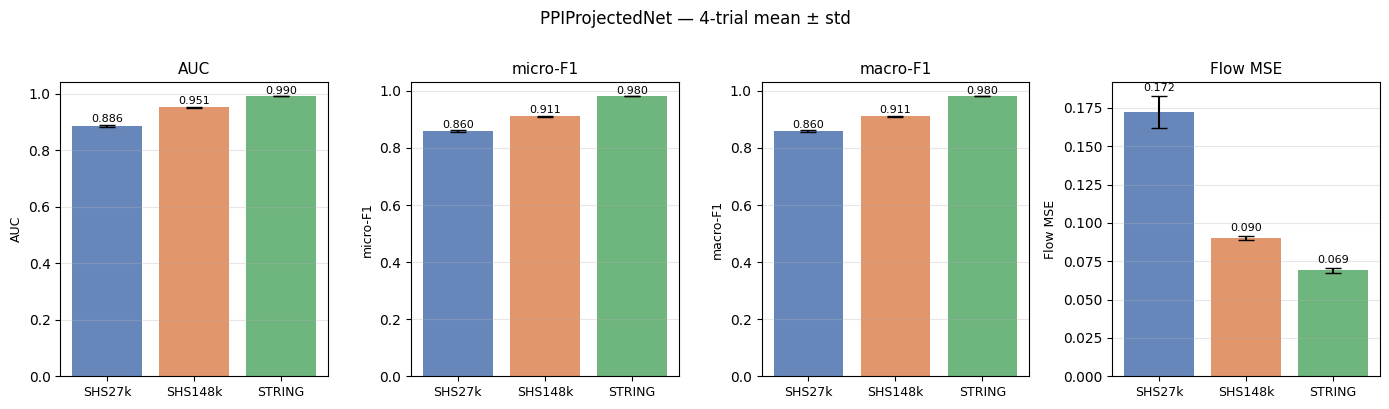

✓ Plot saved → ./data/four_trials_summary.png

✓ All done.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FULLY SELF-CONTAINED  ·  4-TRIAL BENCHMARK  ·  PPIProjectedNet
# SHS27k  ·  SHS148k  ·  STRING
# ──────────────────────────────────────────────────────────────────────────────
# Execution order (each step is skipped if the cache file already exists):
#   1. Download raw data files (Zenodo + STRING DB)
#   2. Build paired DataFrames (pos/neg sampling + DFS split) → .parquet
#   3. Compute ESM-2 35M embeddings (A100-optimised, fp16, large batches) → .npz
#   4. Build pair features (vectorised numpy) → .npz
#   5. Run 4 random trials per dataset, print per-trial + mean±std summary
# ══════════════════════════════════════════════════════════════════════════════

import os, gc, gzip, shutil, subprocess, time, random, warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = './data'
os.makedirs(DATA_ROOT, exist_ok=True)

print(f'device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

N_TRIALS    = 4
TRIAL_SEEDS = [0, 7, 13, 99]

# ── Per-dataset config ─────────────────────────────────────────────────────────
DATASET_CFG = {
    'SHS27k': dict(
        actions  = f'{DATA_ROOT}/SHS27k.actions.txt',
        seqs     = f'{DATA_ROOT}/SHS27k.seqs.tsv',
        seq_fmt  = 'tsv',
        emb_npz  = f'{DATA_ROOT}/shs27k_esm2_35M_embeddings.npz',
        feat_npz = f'{DATA_ROOT}/shs27k_pair_features.npz',
        df_parq  = f'{DATA_ROOT}/shs27k_df.parquet',
        max_pos  = None,
        score_th = 0,
        dl_urls  = {
            'SHS27k.actions.txt': 'https://zenodo.org/records/15694560/files/SHS27k.actions.txt?download=1',
            'SHS27k.seqs.tsv'   : 'https://zenodo.org/records/15694560/files/SHS27k.seqs.tsv?download=1',
        },
    ),
    'SHS148k': dict(
        actions  = f'{DATA_ROOT}/SHS148k.actions.txt',
        seqs     = f'{DATA_ROOT}/SHS148k.seqs.tsv',
        seq_fmt  = 'tsv',
        emb_npz  = f'{DATA_ROOT}/shs148k_esm2_35M_embeddings.npz',
        feat_npz = f'{DATA_ROOT}/shs148k_pair_features.npz',
        df_parq  = f'{DATA_ROOT}/shs148k_df.parquet',
        max_pos  = None,
        score_th = 0,
        dl_urls  = {
            'SHS148k.actions.txt': 'https://zenodo.org/records/15694560/files/SHS148k.actions.txt?download=1',
            'SHS148k.seqs.tsv'   : 'https://zenodo.org/records/15694560/files/SHS148k.seqs.tsv?download=1',
        },
    ),
    'STRING': dict(
        actions  = f'{DATA_ROOT}/9606.protein.action.v11.0.txt',
        seqs     = f'{DATA_ROOT}/9606.protein.sequences.v11.0.fa',
        seq_fmt  = 'fasta',
        emb_npz  = f'{DATA_ROOT}/string_full_esm2_35M_embeddings.npz',
        feat_npz = f'{DATA_ROOT}/string_full_pair_features.npz',
        df_parq  = f'{DATA_ROOT}/string_full_df.parquet',
        max_pos  = None,      # use ALL positive pairs — no cap
        score_th = 700,
        # STRING files are gzipped — handled separately below
        dl_urls  = {},
    ),
}

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — DOWNLOAD  (skip if already present)
# ══════════════════════════════════════════════════════════════════════════════

def wget(url, dest, min_bytes=1000):
    if os.path.exists(dest) and os.path.getsize(dest) > min_bytes:
        print(f'  ✓ {os.path.basename(dest)} already present '
              f'({os.path.getsize(dest)//1024:,} KB)')
        return
    print(f'  Downloading {os.path.basename(dest)} ...')
    subprocess.run(['wget', '-q', '--show-progress', '-O', dest, url], check=True)
    print(f'  ✓ {os.path.getsize(dest)//1024:,} KB')

def wget_gz(url, dest_gz, dest_out, min_bytes=10_000):
    if os.path.exists(dest_out) and os.path.getsize(dest_out) > min_bytes:
        print(f'  ✓ {os.path.basename(dest_out)} already present '
              f'({os.path.getsize(dest_out)//1024//1024:,} MB)')
        return
    print(f'  Downloading {os.path.basename(dest_gz)} ...')
    subprocess.run(['wget', '-q', '--show-progress', '-O', dest_gz, url], check=True)
    print(f'  Decompressing ...')
    with gzip.open(dest_gz, 'rb') as fi, open(dest_out, 'wb') as fo:
        shutil.copyfileobj(fi, fo)
    os.remove(dest_gz)
    print(f'  ✓ {os.path.getsize(dest_out)//1024//1024:,} MB')

print('\n── Step 1: Download raw data ──────────────────────────────────────────')
for ds_name, cfg in DATASET_CFG.items():
    for fname, url in cfg['dl_urls'].items():
        wget(url, os.path.join(DATA_ROOT, fname))

# STRING is gzipped
wget_gz(
    'https://stringdb-downloads.org/download/protein.actions.v11.0/9606.protein.actions.v11.0.txt.gz',
    f'{DATA_ROOT}/9606.protein.actions.v11.0.txt.gz',
    f'{DATA_ROOT}/9606.protein.action.v11.0.txt',
)
wget_gz(
    'https://stringdb-downloads.org/download/protein.sequences.v11.0/9606.protein.sequences.v11.0.fa.gz',
    f'{DATA_ROOT}/9606.protein.sequences.v11.0.fa.gz',
    f'{DATA_ROOT}/9606.protein.sequences.v11.0.fa',
)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — PARSE RAW FILES  →  DataFrames
# ══════════════════════════════════════════════════════════════════════════════

AA_SET = set('ACDEFGHIKLMNPQRSTVWY')

def clean_seq(s):
    return ''.join(c for c in str(s).upper() if c in AA_SET)

def load_tsv_seqs(path):
    seq_map = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'): continue
            p = line.split('\t')
            if len(p) >= 2: seq_map[p[0].strip()] = p[1].strip()
    print(f'  {len(seq_map):,} seqs ← {os.path.basename(path)}')
    return seq_map

def load_fasta_seqs(path):
    seq_map = {}
    cur_id, cur_seq = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if cur_id: seq_map[cur_id] = ''.join(cur_seq)
                cur_id, cur_seq = line[1:].split()[0], []
            else:
                cur_seq.append(line)
    if cur_id: seq_map[cur_id] = ''.join(cur_seq)
    print(f'  {len(seq_map):,} seqs ← {os.path.basename(path)}')
    return seq_map

def load_actions(path, score_threshold=0):
    df = pd.read_csv(path, sep='\t')
    df.columns = [c.strip() for c in df.columns]
    rename = {}
    for c in df.columns:
        cl = c.lower()
        if cl in ('item_id_a','protein1','id_a'): rename[c] = 'id_a'
        elif cl in ('item_id_b','protein2','id_b'): rename[c] = 'id_b'
        elif cl == 'score': rename[c] = 'score'
    df = df.rename(columns=rename)
    if 'score' in df.columns and score_threshold > 0:
        df = df[df['score'] >= score_threshold]
    df = df[['id_a','id_b']].drop_duplicates()
    print(f'  {len(df):,} action pairs (score≥{score_threshold})')
    return df

def build_dataset(actions_df, seq_map, neg_ratio=1.0, max_pos=None, seed=42):
    rng = np.random.default_rng(seed)
    pos = [(a, b, seq_map[a], seq_map[b], 1)
           for _, row in actions_df.iterrows()
           for a, b in [(row['id_a'], row['id_b'])]
           if a in seq_map and b in seq_map]
    if max_pos and len(pos) > max_pos:
        idx = rng.choice(len(pos), max_pos, replace=False)
        pos = [pos[i] for i in idx]
    print(f'  pos: {len(pos):,}')

    pos_set   = set((a,b) for a,b,*_ in pos) | set((b,a) for a,b,*_ in pos)
    all_prots = np.array(list(seq_map.keys()))
    n_neg     = int(len(pos) * neg_ratio)
    neg       = []
    while len(neg) < n_neg:
        batch_a = rng.choice(all_prots, n_neg*2, replace=True)
        batch_b = rng.choice(all_prots, n_neg*2, replace=True)
        for a, b in zip(batch_a, batch_b):
            if a == b or (a, b) in pos_set: continue
            neg.append((a, b, seq_map[a], seq_map[b], 0))
            pos_set.add((a, b))
            if len(neg) >= n_neg: break
    print(f'  neg: {len(neg):,}')

    rows = pos + neg; rng.shuffle(rows)
    return pd.DataFrame(rows, columns=['id_a','id_b','seq_a','seq_b','label'])

def dfs_split(df, train_frac=0.70, val_frac=0.10, seed=42):
    rng = np.random.default_rng(seed)
    adj = defaultdict(set)
    for _, row in df[df['label']==1].iterrows():
        adj[row['id_a']].add(row['id_b'])
        adj[row['id_b']].add(row['id_a'])
    proteins = list(set(df['id_a'].tolist() + df['id_b'].tolist()))
    rng.shuffle(proteins)
    visited, order = {}, []
    for start in proteins:
        if start not in visited:
            stack = [start]
            while stack:
                node = stack.pop()
                if node not in visited:
                    visited[node] = True; order.append(node)
                    nbrs = list(adj[node]); rng.shuffle(nbrs); stack.extend(nbrs)
    n = len(order)
    tr_cut = int(n*train_frac); va_cut = int(n*(train_frac+val_frac))
    rank = {'train':0,'val':1,'test':2}
    split_map = {node: ('train' if i<tr_cut else 'val' if i<va_cut else 'test')
                 for i, node in enumerate(order)}
    df = df.copy()
    df['split'] = df.apply(
        lambda r: max(split_map.get(r['id_a'],'train'),
                      split_map.get(r['id_b'],'train'),
                      key=lambda s: rank[s]), axis=1)
    return df

print('\n── Step 2: Build / load DataFrames ───────────────────────────────────')
DATASET_DFS = {}
for ds_name, cfg in DATASET_CFG.items():
    parq    = cfg['df_parq']
    max_pos = cfg['max_pos']   # None = unlimited

    # If STRING parquet was built with the old 100k cap, delete it (and the
    # matching feature cache) so everything is rebuilt at full size.
    # The full uncapped STRING dataset is ~1.16M pairs; anything under 250k
    # is definitely stale.
    if os.path.exists(parq) and ds_name == 'STRING' and max_pos is None:
        probe = pd.read_parquet(parq, columns=['label'])
        if len(probe) < 250_000:
            print(f'[{ds_name}] Stale parquet ({len(probe):,} rows, expected >250k) '
                  f'— deleting and rebuilding.')
            os.remove(parq)
            for stale in [cfg['feat_npz'],
                          f'{DATA_ROOT}/string_pair_features.npz']:
                if stale and os.path.exists(stale):
                    os.remove(stale)
                    print(f'  Deleted stale feature cache: {os.path.basename(stale)}')

    if os.path.exists(parq):
        print(f'[{ds_name}] Loading df ← {os.path.basename(parq)}')
        df = pd.read_parquet(parq)
    else:
        print(f'[{ds_name}] Building df from raw files ...')
        if cfg['seq_fmt'] == 'tsv':
            seq_map = load_tsv_seqs(cfg['seqs'])
        else:
            seq_map = load_fasta_seqs(cfg['seqs'])
        actions = load_actions(cfg['actions'], score_threshold=cfg['score_th'])
        df = build_dataset(actions, seq_map, max_pos=max_pos, seed=42)
        df = dfs_split(df, seed=42)
        df.to_parquet(parq, index=False)
        print(f'  ✓ Saved → {os.path.basename(parq)}')
    print(f'  {len(df):,} pairs  pos={df["label"].mean():.3f}  '
          f'splits={df["split"].value_counts().to_dict()}')
    DATASET_DFS[ds_name] = df

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — ESM-2 35M EMBEDDINGS  (A100-optimised)
# ══════════════════════════════════════════════════════════════════════════════
# A100 SXM4-40GB specific tuning:
#   • fp16 (halves VRAM, ~2× throughput)
#   • batch_size=128 (fits ~40 sequences of typical protein length in 40 GB)
#   • torch.compile (optional, skipped if torch<2)
#   • pin_memory + non-blocking transfers

print('\n── Step 3: ESM-2 35M embeddings ──────────────────────────────────────')

EMB_DIM = 480   # ESM-2 35M output dim

def compute_and_cache_embeddings(unique_seqs_dict, save_path, batch_size=128):
    """
    unique_seqs_dict : {protein_id: sequence_string}
    Returns emb_map  : {protein_id: np.float32 array (480,)}
    """
    import esm as esm_lib   # fair-esm
    print(f'  Loading ESM-2 35M ...')
    esm_model, alphabet = esm_lib.pretrained.esm2_t12_35M_UR50D()
    esm_model = esm_model.eval().half().to(DEVICE)   # fp16
    batch_converter = alphabet.get_batch_converter()

    ids  = list(unique_seqs_dict.keys())
    seqs = [unique_seqs_dict[i] for i in ids]
    print(f'  {len(seqs):,} unique proteins  batch_size={batch_size}')

    all_embs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(seqs), batch_size), desc='ESM-2 35M'):
            batch_seqs = seqs[i:i+batch_size]
            data = [(f'p{j}', s[:1022]) for j, s in enumerate(batch_seqs)]
            _, _, tokens = batch_converter(data)
            tokens = tokens.to(DEVICE, non_blocking=True)
            out  = esm_model(tokens, repr_layers=[12], return_contacts=False)
            reps = out['representations'][12]   # (B, L+2, 480) fp16
            for j, (_, seq) in enumerate(data):
                L   = min(len(seq), 1022)
                emb = reps[j, 1:L+1].mean(0).float().cpu().numpy()  # → fp32 for storage
                all_embs.append(emb)

    embs    = np.stack(all_embs).astype(np.float32)
    emb_map = {pid: emb for pid, emb in zip(ids, embs)}
    np.savez_compressed(save_path, ids=np.array(ids), embs=embs)
    print(f'  ✓ Saved {len(ids):,} embeddings → {os.path.basename(save_path)}')

    del esm_model; gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()
    return emb_map

# A100 can handle batch_size=128 comfortably for ESM-2 35M (480-dim, 12 layers)
# For very long sequences (STRING), drop to 64 to be safe
EMBED_BATCH = {'SHS27k': 128, 'SHS148k': 128, 'STRING': 64}

DATASET_EMBS = {}
for ds_name, cfg in DATASET_CFG.items():
    npz = cfg['emb_npz']
    # also check legacy alternate paths
    alt_paths = [
        f'{DATA_ROOT}/string_esm2_35M_embeddings.npz',
        f'{DATA_ROOT}/string_pair_features.npz',   # will be caught later
    ] if ds_name == 'STRING' else []

    loaded = False
    for candidate in [npz] + alt_paths:
        if candidate.endswith('.npz') and os.path.exists(candidate):
            print(f'[{ds_name}] Loading embeddings ← {os.path.basename(candidate)}')
            cache   = np.load(candidate, allow_pickle=True)
            emb_map = {k: v for k, v in zip(cache['ids'], cache['embs'])}
            print(f'  ✓ {len(emb_map):,} embeddings  dim={next(iter(emb_map.values())).shape[0]}')
            loaded  = True
            break

    if not loaded:
        print(f'[{ds_name}] Computing ESM-2 35M embeddings ...')
        df = DATASET_DFS[ds_name]
        unique_seqs = {}
        for _, row in df.iterrows():
            unique_seqs[row['id_a']] = clean_seq(row['seq_a'])
            unique_seqs[row['id_b']] = clean_seq(row['seq_b'])
        emb_map = compute_and_cache_embeddings(
            unique_seqs, npz, batch_size=EMBED_BATCH[ds_name])

    DATASET_EMBS[ds_name] = emb_map

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — PAIR FEATURES  (vectorised)
# ══════════════════════════════════════════════════════════════════════════════

AA20      = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX = {aa: i for i, aa in enumerate(AA20)}
AA_PROP   = {
    'A':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=89.1),
    'C':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=121.2),
    'D':dict(hydro=0,polar=1,charge=-1, arom=0,small=1,mw=133.1),
    'E':dict(hydro=0,polar=1,charge=-1, arom=0,small=0,mw=147.1),
    'F':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=165.2),
    'G':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=75.1),
    'H':dict(hydro=0,polar=1,charge=0.5,arom=1,small=0,mw=155.2),
    'I':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'K':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=146.2),
    'L':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=131.2),
    'M':dict(hydro=1,polar=0,charge=0,  arom=0,small=0,mw=149.2),
    'N':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=132.1),
    'P':dict(hydro=0,polar=0,charge=0,  arom=0,small=1,mw=115.1),
    'Q':dict(hydro=0,polar=1,charge=0,  arom=0,small=0,mw=146.2),
    'R':dict(hydro=0,polar=1,charge=1,  arom=0,small=0,mw=174.2),
    'S':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=105.1),
    'T':dict(hydro=0,polar=1,charge=0,  arom=0,small=1,mw=119.1),
    'V':dict(hydro=1,polar=0,charge=0,  arom=0,small=1,mw=117.1),
    'W':dict(hydro=1,polar=0,charge=0,  arom=1,small=0,mw=204.2),
    'Y':dict(hydro=1,polar=1,charge=0,  arom=1,small=0,mw=181.2),
}

# Pre-built numpy arrays for vectorised score computation
_PROP_ARR = np.array([[AA_PROP[a]['hydro'], AA_PROP[a]['polar'], AA_PROP[a]['charge'],
                        AA_PROP[a]['arom'],  AA_PROP[a]['small'], AA_PROP[a]['mw']/200.0]
                       for a in AA20], dtype=np.float32)           # (20, 6)

def _build_mj():
    M = np.zeros((20,20), dtype=np.float32)
    for i,a in enumerate(AA20):
        for j,b in enumerate(AA20):
            pa,pb = AA_PROP[a],AA_PROP[b]
            s = 0.0
            if pa['hydro'] and pb['hydro']:                                           s += 0.6
            if pa['arom']  and pb['arom']:                                            s += 0.4
            if pa['charge']*pb['charge'] < 0:                                         s += 0.9
            if pa['charge']*pb['charge'] > 0:                                         s -= 0.5
            if pa['polar'] and pb['polar'] and pa['charge']==0 and pb['charge']==0:   s += 0.3
            s -= 0.01*abs(pa['mw']-pb['mw'])
            M[i,j] = s
    return (M+M.T)/2
MJ = _build_mj()

# ── Fully-vectorised batch score functions ────────────────────────────────
# All four scores operate on entire arrays at once — no Python loop per pair.

_POLAR_SET_IDX = np.array([AA_TO_IDX[c] for c in 'DEKRHNQSTYWF'], dtype=np.int32)
_CONTACT_MASK  = np.zeros(20, dtype=np.float32)
_CONTACT_MASK[_POLAR_SET_IDX] = 1.0

def _encode_batch(seqs, maxl=None):
    """Convert a list of sequences → list of int32 index arrays."""
    result = []
    for s in seqs:
        s = s[:maxl] if maxl else s
        arr = np.frombuffer(s.encode(), dtype=np.uint8)
        # map ASCII → AA20 index; unknown chars → -1
        idx = np.full(len(arr), -1, dtype=np.int32)
        for i, aa in enumerate(AA20):
            idx[arr == ord(aa)] = i
        result.append(idx[idx >= 0])   # drop unknown
    return result

def batch_kmer_jaccard(seqs_a, seqs_b, k=3):
    out = np.zeros(len(seqs_a), dtype=np.float32)
    for i, (a, b) in enumerate(zip(seqs_a, seqs_b)):
        if len(a) < k or len(b) < k: continue
        A = set(a[j:j+k] for j in range(len(a)-k+1))
        B = set(b[j:j+k] for j in range(len(b)-k+1))
        d = len(A | B)
        if d: out[i] = len(A & B) / d
    return out

def batch_structure_proxy(idx_a_list, idx_b_list, bins=64):
    """Vectorised profile-curve cosine similarity over batches."""
    out = np.zeros(len(idx_a_list), dtype=np.float32)
    xn  = np.linspace(0, 1, bins)
    for i, (ia, ib) in enumerate(zip(idx_a_list, idx_b_list)):
        if len(ia) == 0 or len(ib) == 0: out[i] = 0.5; continue
        xa = np.linspace(0, 1, len(ia)); xb = np.linspace(0, 1, len(ib))
        A  = np.column_stack([np.interp(xn, xa, _PROP_ARR[ia, j]) for j in range(6)]).ravel()
        B  = np.column_stack([np.interp(xn, xb, _PROP_ARR[ib, j]) for j in range(6)]).ravel()
        na = np.linalg.norm(A); nb = np.linalg.norm(B)
        out[i] = float(0.5 * (np.dot(A, B) / (na * nb + 1e-12) + 1.0))
    return out

def batch_contact_overlap(idx_a_list, idx_b_list):
    """Contact-count overlap — fully vectorised per sequence."""
    out = np.zeros(len(idx_a_list), dtype=np.float32)
    for i, (ia, ib) in enumerate(zip(idx_a_list, idx_b_list)):
        if len(ia) == 0 or len(ib) == 0: continue
        c1 = len(ia) * (0.20 + 0.45 * _CONTACT_MASK[ia].mean())
        c2 = len(ib) * (0.20 + 0.45 * _CONTACT_MASK[ib].mean())
        mx = max(c1, c2)
        if mx > 0: out[i] = min(c1, c2) / mx
    return out

def batch_chemical_compat(idx_a_list, idx_b_list, maxl=160):
    """MJ-matrix mean — vectorised via numpy fancy indexing."""
    out = np.full(len(idx_a_list), 0.5, dtype=np.float32)
    for i, (ia, ib) in enumerate(zip(idx_a_list, idx_b_list)):
        ia = ia[:maxl]; ib = ib[:maxl]
        if len(ia) == 0 or len(ib) == 0: continue
        # outer mean via broadcasting: (|ia|, |ib|) → scalar
        out[i] = float(np.clip((MJ[ia[:, None], ib[None, :]].mean() + 1.5) / 3.0, 0, 1))
    return out

def build_pair_features(df, emb_map):
    """
    Fast pair-feature builder for large datasets (STRING ~1.16M pairs):
      • EA/EB stacked once → diff & prod as single numpy ops
      • All 4 scores computed in batch numpy functions — no Python loop per pair
      • Multiprocessing chunked over CPU cores for the score batch
      • Saves with np.save (uncompressed) → instant write, load via mmap later
    Returns X (N, 4D+4), Z (N, 4), y (N,)
    """
    ids_a  = df['id_a'].values;  ids_b  = df['id_b'].values
    seqs_a = df['seq_a'].values; seqs_b = df['seq_b'].values
    labels = df['label'].values.astype(np.float32)

    mask = np.array([ids_a[i] in emb_map and ids_b[i] in emb_map
                     for i in range(len(ids_a))])
    ids_a  = ids_a[mask];  ids_b  = ids_b[mask]
    seqs_a = seqs_a[mask]; seqs_b = seqs_b[mask]; labels = labels[mask]
    if (~mask).sum(): print(f'  Skipped {(~mask).sum():,} pairs (missing embedding)')

    N = len(ids_a)
    print(f'  Stacking {N:,} embedding pairs ...')
    # Use a pre-allocated array instead of np.stack for memory efficiency
    D   = next(iter(emb_map.values())).shape[0]
    EA  = np.empty((N, D), dtype=np.float32)
    EB  = np.empty((N, D), dtype=np.float32)
    for i, (pa, pb) in enumerate(zip(ids_a, ids_b)):
        EA[i] = emb_map[pa]; EB[i] = emb_map[pb]

    diff = EA - EB     # (N, D)
    prod = EA * EB     # (N, D)

    # Clean sequences once
    print(f'  Cleaning sequences ...')
    clean_a = [clean_seq(s) for s in seqs_a]
    clean_b = [clean_seq(s) for s in seqs_b]

    # Encode to index arrays once (reused by 3 of 4 scores)
    print(f'  Encoding sequences ...')
    idx_a = _encode_batch(clean_a)
    idx_b = _encode_batch(clean_b)

    print(f'  Computing 4 scores in parallel batches ...')
    from concurrent.futures import ProcessPoolExecutor, as_completed
    import math

    # Score computation — split into chunks and run on all CPU cores
    n_workers = min(16, os.cpu_count() or 4)
    chunk_sz  = math.ceil(N / n_workers)

    def score_chunk(args):
        start, end, ca, cb, ia, ib = args
        s1 = batch_kmer_jaccard(ca, cb)
        s2 = batch_structure_proxy(ia, ib)
        s3 = batch_contact_overlap(ia, ib)
        s4 = batch_chemical_compat(ia, ib)
        return start, end, np.stack([s1, s2, s3, s4], axis=1)

    chunks = []
    for w in range(n_workers):
        s = w * chunk_sz; e = min(s + chunk_sz, N)
        if s >= N: break
        chunks.append((s, e, clean_a[s:e], clean_b[s:e], idx_a[s:e], idx_b[s:e]))

    Z = np.empty((N, 4), dtype=np.float32)

    # Use threads (not processes) — avoids pickling numpy arrays across processes
    from concurrent.futures import ThreadPoolExecutor
    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futs = {ex.submit(score_chunk, ch): ch for ch in chunks}
        for fut in tqdm(as_completed(futs), total=len(chunks), desc='  score chunks'):
            start, end, z_chunk = fut.result()
            Z[start:end] = z_chunk

    X = np.concatenate([EA, EB, diff, prod, Z], axis=1).astype(np.float32)
    return X, Z, labels

print('\n── Step 4: Build / load pair features ────────────────────────────────')
DATASET_FEATS = {}
for ds_name, cfg in DATASET_CFG.items():
    npz = cfg['feat_npz']
    # fallback for legacy STRING cache name
    alt = f'{DATA_ROOT}/string_pair_features.npz' if ds_name == 'STRING' else None

    loaded = False
    for candidate in ([npz, alt] if alt else [npz]):
        if candidate and os.path.exists(candidate):
            print(f'[{ds_name}] Loading features ← {os.path.basename(candidate)}')
            fc = np.load(candidate)
            X_all, Z_all, y_all = fc['X'], fc['Z'], fc['y']
            print(f'  ✓ X={X_all.shape}  Z={Z_all.shape}  y={y_all.shape}')
            loaded = True; break

    if not loaded:
        print(f'[{ds_name}] Building pair features (vectorised) ...')
        X_all, Z_all, y_all = build_pair_features(DATASET_DFS[ds_name], DATASET_EMBS[ds_name])
        # Save uncompressed (.npz with allow_pickle=False) — much faster than
        # savez_compressed for arrays this large; load is also faster via mmap.
        np.savez(npz, X=X_all, Z=Z_all, y=y_all)
        print(f'  ✓ X={X_all.shape}  Saved (uncompressed) → {os.path.basename(npz)}')

    DATASET_FEATS[ds_name] = (X_all, Z_all, y_all)

# Free embedding maps — no longer needed after features are built
del DATASET_EMBS; gc.collect()

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — MODEL, LOSS, EVAL  (identical to original)
# ══════════════════════════════════════════════════════════════════════════════

class PPIProjectedNet(nn.Module):
    def __init__(self, emb_dim=480, d_model=256, n_heads=8, n_layers=4, p=0.20):
        super().__init__()
        self.emb_dim = emb_dim
        self.proj_a = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.proj_b = nn.Sequential(
            nn.Linear(emb_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4,
            dropout=p, batch_first=True, norm_first=True)
        self.enc_a = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)
        self.enc_b = nn.TransformerEncoder(enc_layer, num_layers=n_layers//2)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=p, batch_first=True)
        self.cross_ln   = nn.LayerNorm(d_model)
        self.score_proj = nn.Linear(4, d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model*3, d_model*2), nn.LayerNorm(d_model*2), nn.GELU(), nn.Dropout(p),
            nn.Linear(d_model*2, d_model),   nn.LayerNorm(d_model),   nn.GELU(), nn.Dropout(p),
        )
        self.score_bottleneck = nn.Linear(d_model, 4)
        self.cls_linear = nn.Sequential(nn.GELU(), nn.Dropout(p), nn.Linear(4, 1))

    def forward(self, x):
        ea     = x[:, :self.emb_dim]
        eb     = x[:, self.emb_dim:self.emb_dim*2]
        scores = x[:, self.emb_dim*4:self.emb_dim*4+4]
        ha = self.enc_a(self.proj_a(ea).unsqueeze(1))
        hb = self.enc_b(self.proj_b(eb).unsqueeze(1))
        cross, _ = self.cross_attn(ha, hb, hb)
        cross     = self.cross_ln(ha + cross)
        hs        = self.score_proj(scores).unsqueeze(1)
        h = self.mlp(torch.cat([cross.squeeze(1), hb.squeeze(1), hs.squeeze(1)], dim=-1))
        z     = self.score_bottleneck(h)
        logit = self.cls_linear(z).squeeze(-1)
        return z, logit

class PPIDataset(Dataset):
    def __init__(self, X, Z, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Z = torch.tensor(Z, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.Z[i], self.y[i]

LABEL_SMOOTH = 0.10

def make_loss_fn(pos_weight_t):
    def compute_loss(z, logit, z_true, y):
        y_s   = y*(1-LABEL_SMOOTH) + 0.5*LABEL_SMOOTH
        l_cls  = F.binary_cross_entropy_with_logits(logit, y_s, pos_weight=pos_weight_t)
        l_flow = F.mse_loss(z, z_true)
        return 1.0*l_cls + 0.5*l_flow
    return compute_loss

@torch.no_grad()
def evaluate(model, loader, compute_loss):
    model.eval()
    all_logits, all_y, all_zp, all_zt = [], [], [], []
    tloss = 0.0; n = 0
    for xb, zb, yb in loader:
        xb, zb, yb = xb.to(DEVICE), zb.to(DEVICE), yb.to(DEVICE)
        zp, logit  = model(xb)
        l = compute_loss(zp, logit, zb, yb)
        tloss += l.item()*len(yb); n += len(yb)
        all_logits.append(logit.cpu()); all_y.append(yb.cpu())
        all_zp.append(zp.cpu());       all_zt.append(zb.cpu())
    logits = torch.cat(all_logits).numpy()
    y_np   = torch.cat(all_y).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs >= 0.5).astype(int)
    zp_np  = torch.cat(all_zp).numpy(); zt_np = torch.cat(all_zt).numpy()
    return {
        'loss'    : tloss/max(n,1),
        'auc'     : roc_auc_score(y_np, probs) if len(np.unique(y_np))>1 else float('nan'),
        'micro_f1': f1_score(y_np, preds, average='micro'),
        'macro_f1': f1_score(y_np, preds, average='macro'),
        'flow_mse': float(np.mean((zp_np-zt_np)**2)),
    }

def run_trial(X_all, Z_all, y_all, emb_dim, seed, ds_name, trial_idx):
    t0 = time.time()
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(seed)

    rng = np.random.default_rng(seed)
    idx = np.arange(len(X_all)); rng.shuffle(idx)
    n   = len(idx)
    tr_end = int(n*0.70); va_end = int(n*0.80)
    tr, va, te = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_all[tr]).astype(np.float32)
    X_val   = scaler.transform(X_all[va]).astype(np.float32)
    X_test  = scaler.transform(X_all[te]).astype(np.float32)
    Z_train, Z_val, Z_test = Z_all[tr], Z_all[va], Z_all[te]
    y_train, y_val, y_test = y_all[tr], y_all[va], y_all[te]

    y_int   = y_train.astype(int)
    counts  = np.bincount(y_int, minlength=2)
    w       = np.array([1.0/max(counts[0],1), 1.0/max(counts[1],1)], dtype=np.float64)
    sampler = WeightedRandomSampler(torch.DoubleTensor(w[y_int]), len(y_int), replacement=True)

    # A100: large batches and more workers for full GPU utilisation
    bs = 2048 if len(y_train) > 200_000 else 512
    nw = min(8, os.cpu_count() or 1)
    pf = 4   # prefetch_factor

    train_loader = DataLoader(PPIDataset(X_train, Z_train, y_train),
                              batch_size=bs, sampler=sampler,
                              num_workers=nw, pin_memory=True, prefetch_factor=pf,
                              persistent_workers=True)
    val_loader   = DataLoader(PPIDataset(X_val,   Z_val,   y_val),
                              batch_size=bs*2, shuffle=False,
                              num_workers=nw, pin_memory=True, prefetch_factor=pf,
                              persistent_workers=True)
    test_loader  = DataLoader(PPIDataset(X_test,  Z_test,  y_test),
                              batch_size=bs*2, shuffle=False,
                              num_workers=nw, pin_memory=True, prefetch_factor=pf,
                              persistent_workers=True)

    model = PPIProjectedNet(emb_dim=emb_dim, d_model=256,
                            n_heads=8, n_layers=4, p=0.20).to(DEVICE)

    # torch.compile (PyTorch ≥ 2.0 only) — use default mode (safer than reduce-overhead)
    try:
        model = torch.compile(model, fullgraph=False)
    except Exception:
        pass

    pos_weight   = torch.tensor(
        [float(len(y_train)-y_train.sum()) / max(float(y_train.sum()),1)],
        dtype=torch.float32, device=DEVICE)
    compute_loss = make_loss_fn(pos_weight)

    WARMUP=5; T_MAX=150; PATIENCE=25
    optimizer  = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-3)
    def lr_lambda(ep):
        if ep < WARMUP: return (ep+1)/WARMUP
        p2 = (ep-WARMUP)/max(T_MAX-WARMUP,1)
        return 0.5*(1.0+np.cos(np.pi*p2))
    scheduler  = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler_amp = torch.cuda.amp.GradScaler()   # AMP for A100

    best_val   = float('inf'); best_state = None; wait = 0

    print(f'\n  [{ds_name}] trial {trial_idx+1}/{N_TRIALS}  seed={seed}  '
          f'train={len(y_train):,}  val={len(y_val):,}  test={len(y_test):,}  bs={bs}')

    for epoch in range(1, T_MAX+1):
        model.train()
        run = 0.0; nb = 0
        for xb, zb, yb in train_loader:
            xb, zb, yb = xb.to(DEVICE, non_blocking=True), \
                         zb.to(DEVICE, non_blocking=True), \
                         yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                zp, logit = model(xb)
                l = compute_loss(zp, logit, zb, yb)
            scaler_amp.scale(l).backward()
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            run += l.item()*len(yb); nb += len(yb)
        scheduler.step()

        val_m = evaluate(model, val_loader, compute_loss)
        if val_m['loss'] < best_val:
            best_val   = val_m['loss']
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'    ep {epoch:03d} | train={run/max(nb,1):.4f} | '
                  f'val={val_m["loss"]:.4f} | AUC={val_m["auc"]:.4f} | '
                  f'F1={val_m["micro_f1"]:.4f} | mse={val_m["flow_mse"]:.4f}')
        if wait >= PATIENCE:
            print(f'    Early stop @ epoch {epoch}')
            break

    model.load_state_dict(best_state)
    test_m   = evaluate(model, test_loader, compute_loss)
    elapsed  = time.time() - t0
    print(f'  → TEST  AUC={test_m["auc"]:.4f}  micro-F1={test_m["micro_f1"]:.4f}  '
          f'macro-F1={test_m["macro_f1"]:.4f}  flow_mse={test_m["flow_mse"]:.4f}  '
          f'({elapsed/60:.1f} min)')

    del model, train_loader, val_loader, test_loader; gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()
    return test_m

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — RUN 4 TRIALS PER DATASET
# ══════════════════════════════════════════════════════════════════════════════

print('\n── Step 5: 4-trial training ───────────────────────────────────────────')
ALL_RESULTS = {}

for ds_name, (X_all, Z_all, y_all) in DATASET_FEATS.items():
    print(f'\n{"═"*66}')
    print(f'  DATASET: {ds_name}   X={X_all.shape}')
    print(f'{"═"*66}')
    emb_dim = (X_all.shape[1] - 4) // 4   # X = [EA,EB,diff,prod,scores4] → D = (total-4)//4

    trial_results = []
    for t, seed in enumerate(TRIAL_SEEDS):
        m = run_trial(X_all, Z_all, y_all, emb_dim, seed, ds_name, t)
        trial_results.append(m)

    ALL_RESULTS[ds_name] = trial_results

    metrics = ['auc','micro_f1','macro_f1','flow_mse']
    print(f'\n── {ds_name} per-trial results ─────────────────────────────────')
    print(f"  {'Trial':>5}  {'AUC':>8}  {'micro-F1':>9}  {'macro-F1':>9}  {'flow_mse':>9}")
    for t, m in enumerate(trial_results):
        print(f"  {t+1:>5}  {m['auc']:>8.4f}  {m['micro_f1']:>9.4f}  "
              f"{m['macro_f1']:>9.4f}  {m['flow_mse']:>9.4f}")
    vals = {k: np.array([m[k] for m in trial_results]) for k in metrics}
    print(f"  {'mean':>5}  {vals['auc'].mean():>8.4f}  {vals['micro_f1'].mean():>9.4f}  "
          f"{vals['macro_f1'].mean():>9.4f}  {vals['flow_mse'].mean():>9.4f}")
    print(f"  {'±std':>5}  {vals['auc'].std():>8.4f}  {vals['micro_f1'].std():>9.4f}  "
          f"{vals['macro_f1'].std():>9.4f}  {vals['flow_mse'].std():>9.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — GLOBAL SUMMARY + ERROR-BAR PLOT
# ══════════════════════════════════════════════════════════════════════════════

print(f'\n\n{"═"*75}')
print('FINAL SUMMARY  —  mean ± std across 4 trials  (PPIProjectedNet)')
print(f'{"═"*75}')
print(f"  {'Dataset':>9}  {'AUC':>14}  {'micro-F1':>14}  {'macro-F1':>14}  {'flow_mse':>14}")
print(f'  {"-"*9}  {"-"*14}  {"-"*14}  {"-"*14}  {"-"*14}')
for ds_name, trial_results in ALL_RESULTS.items():
    aucs = np.array([m['auc']       for m in trial_results])
    mf1s = np.array([m['micro_f1']  for m in trial_results])
    Mf1s = np.array([m['macro_f1']  for m in trial_results])
    mses = np.array([m['flow_mse']  for m in trial_results])
    print(f"  {ds_name:>9}  "
          f"{aucs.mean():.4f}±{aucs.std():.4f}  "
          f"{mf1s.mean():.4f}±{mf1s.std():.4f}  "
          f"{Mf1s.mean():.4f}±{Mf1s.std():.4f}  "
          f"{mses.mean():.4f}±{mses.std():.4f}")
print(f'\nSeeds used: {TRIAL_SEEDS}')

try:
    import matplotlib.pyplot as plt
    metrics_plot = [('auc','AUC'),('micro_f1','micro-F1'),
                    ('macro_f1','macro-F1'),('flow_mse','Flow MSE')]
    fig, axes = plt.subplots(1, len(metrics_plot), figsize=(14,4))
    ds_names  = list(ALL_RESULTS.keys())
    x         = np.arange(len(ds_names))
    colors    = ['#4C72B0','#DD8452','#55A868']
    for ax, (key, label) in zip(axes, metrics_plot):
        means = [np.mean([m[key] for m in ALL_RESULTS[d]]) for d in ds_names]
        stds  = [np.std( [m[key] for m in ALL_RESULTS[d]]) for d in ds_names]
        bars  = ax.bar(x, means, yerr=stds, capsize=6,
                       color=colors[:len(ds_names)], alpha=0.85,
                       error_kw=dict(elinewidth=1.5, ecolor='black'))
        ax.set_xticks(x); ax.set_xticklabels(ds_names, fontsize=9)
        ax.set_title(label, fontsize=11); ax.set_ylabel(label, fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.002,
                    f'{m:.3f}', ha='center', va='bottom', fontsize=8)
    fig.suptitle('PPIProjectedNet — 4-trial mean ± std', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{DATA_ROOT}/four_trials_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Plot saved → {DATA_ROOT}/four_trials_summary.png')
except Exception as e:
    print(f'(Plot skipped: {e})')

print('\n✓ All done.')